# Pipeline de Pré-processamento Geral - EEGBCI (Motor Imagery)

Este notebook implementa o preprocessamento dos dados de EEG Motor Movement/Imagery Dataset (EEGBCI, PhysioNet).

- **Tarefa 1 - Pré-processamento:** seleção de canais sensoriomotores, re-referenciamento (CAR), filtragem (notch 60 Hz + passa-banda 8–30 Hz), ICA robusto com classificação automática de componentes, epoching em 0-4 s pós-evento e normalização.
- **Tarefa 2 - Representações:** a partir das épocas pré-processadas, construímos duas representações complementares, uma clássica (features tabulares por canal, potências de banda relativas, variância, parâmetros de Hjorth e entropia espectral) e uma temporal (sinal bruto por época, entrada natural para CNNs).
- **Tarefa 3 - Redução de dimensionalidade:** aplicação e comparação de PCA, LDA e SelectKBest sobre as features clássicas, com validação cruzada que isola sujeitos inteiros em cada fold (GroupKFold).

### Decisões metodológicas principais

| Etapa | Decisão | Justificativa |
|---|---|---|
| Tarefa | Runs 4, 8 e 12 => MI mão esquerda (T1) vs. direita (T2) | Paradigma canônico de imagética motora no EEGBCI |
| Canais | Córtex sensoriomotor (C3, Cz, C4 e vizinhos) | Foco neurofisiológico em mu/beta |
| Referência | CAR (Common Average Reference) | Padrão em MI para atenuar ruído comum |
| Filtros | Passa-banda 8–30 Hz + notch 60 Hz | Bandas mu e beta; rede elétrica dos EUA |
| ICA | Ajustado por sujeito, em dados pré-epoching | Artefatos são específicos de cada sujeito e não vazam entre eles |
| Épocas | 0 a 4 s pós-evento | Janela típica de MI |
| Normalização | StandardScaler ajustado somente no treino | Evita vazamento treino => teste |
| PCA / LDA | Ajustados somente no treino*| Idem |


## 1. Preparação do ambiente

Todas as dependências já foram instaladas no notebook `Preparação_Ambiente.ipynb`. Nesta seção apenas importamos as bibliotecas que serão usadas no restante do trabalho e fixamos sementes de aleatoriedade para garantir reprodutibilidade.

O bloco a seguir carrega:

- **Utilitários gerais** (`os`, `glob`, `pathlib`, `warnings`, `random`) e bibliotecas numéricas (`numpy`, `pandas`, `matplotlib`, `seaborn`, `tqdm`).
- **Ferramentas de EEG** baseadas em `mne` (incluindo `ICA`) e utilitários de `scipy.signal` / `scipy.stats` usados na extração de features.
- **Stack de Machine Learning** do `scikit-learn` (validação cruzada por grupos, pré-processamento, PCA, LDA, SVM, RandomForest e métricas) + `xgboost`.
- **Stack de Deep Learning** (`tensorflow`/`keras`), preparado para representações temporais.

Por fim, silenciamos warnings e o log do MNE para manter a saída limpa, fixamos `SEED=42` em todos os RNGs relevantes e configuramos o estilo dos gráficos.

In [ ]:
# Imports gerais

# IMPORTS 
import os
import glob
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# EEG 
import mne
from mne.preprocessing import ICA
from scipy import signal as sp_signal
from scipy.stats import entropy as scipy_entropy

# ML
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, balanced_accuracy_score
)
import xgboost as xgb

# DL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# CONFIG 
warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

print(f"MNE: {mne.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponível: {len(tf.config.list_physical_devices('GPU')) > 0}")


MNE: 1.12.1
TensorFlow: 2.21.0
GPU disponível: False


## 2. Carregamento e filtragem dos metadados

Antes de abrir qualquer arquivo `.edf`, partimos do CSV de metadados gerado previamente no notebook `Exploração_Dataset.ipynb`. Esse CSV mapeia, para cada sujeito, todos os 14 runs do EEGBCI com a respectiva tarefa física/mental, duração e caminho completo do arquivo.

Essa seção faz duas coisas:

1. **Localiza e carrega o CSV de metadados**, aceitando um caminho alternativo no diretório local caso o principal não exista.
2. **Filtra apenas os runs de interesse** (runs 4, 8 e 12), que correspondem ao paradigma de imagética motora mão esquerda (`T1`) vs. mão direita (`T2`). Os demais runs (baseline e tarefas físicas) são descartados.

In [15]:
# Localiza o CSV de metadados e carrega-o em DataFrame.

# Ajuste conforme o necessário
DATA_ROOT = Path(r"C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb")
CSV_METADADOS = DATA_ROOT / "eegbci_metadados_completos.csv"

# Caso o CSV não esteja presente, procura em outros locais 
if not CSV_METADADOS.exists():
    alt = Path("eegbci_metadados_completos.csv")
    if alt.exists():
        CSV_METADADOS = alt
        print(f"[aviso] Usando CSV local: {alt.resolve()}")

assert CSV_METADADOS.exists(), f"CSV não encontrado em {CSV_METADADOS}"

df_meta = pd.read_csv(CSV_METADADOS, sep=';')
print(f"Metadados carregados: {len(df_meta)} arquivos, {df_meta['Sujeito_ID'].nunique()} sujeitos")
df_meta.head(3)


Metadados carregados: 140 arquivos, 10 sujeitos


,Nome_do_Arquivo,Sujeito_ID,Run_ID,Tarefa_Fisica_ou_Mental,Taxa_Amostragem_Hz,Duracao_Segundos,Qtd_Canais,Tipos_de_Eventos,Data_Gravacao,Caminho_Completo
0,S004R01.edf,S004,1,"Linha de base (Baseline), olhos abertos",160.0,60.99,64,T0,2009-08-12 16:15:00+00:00,C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\...
1,S004R02.edf,S004,2,"Linha de base (Baseline), olhos fechados",160.0,60.99,64,T0,2009-08-12 16:15:00+00:00,C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\...
2,S004R03.edf,S004,3,Execução Motora: abrir/fechar punho esquerdo o...,160.0,122.99,64,"T1, T0, T2",2009-08-12 16:15:00+00:00,C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\...


In [16]:
# Mantém apenas os runs de MI mão esquerda/direita (runs 04, 08, 12) para o paradigma canônico T1 vs T2.
# FILTRO DE RUNS DE INTERESSE 
# Cada sujeito tem 14 runs (arquivos .edf), e cada run tem um propósito específico:
# Run	Tarefa

# Runs 1, 2 - Baseline 
# Runs 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14 - (imaginação motora) 

# Runs 4, 8, 12 = MI mão esquerda (T1) vs mão direita (T2) 

MI_RUNS = ['04', '08', '12']

df_mi = df_meta[df_meta['Run_ID'].astype(str).str.zfill(2).isin(MI_RUNS)].copy()
df_mi = df_mi.sort_values(['Sujeito_ID', 'Run_ID']).reset_index(drop=True)

print(f"Arquivos MI selecionados: {len(df_mi)}")
print(f"Sujeitos: {df_mi['Sujeito_ID'].unique().tolist()}")
print(f"Runs por sujeito (média): {len(df_mi) / df_mi['Sujeito_ID'].nunique():.1f}")
df_mi[['Sujeito_ID', 'Run_ID', 'Tarefa_Fisica_ou_Mental', 'Duracao_Segundos']].head()


Arquivos MI selecionados: 30
Sujeitos: ['S004', 'S014', 'S015', 'S018', 'S029', 'S032', 'S036', 'S082', 'S087', 'S095']
Runs por sujeito (média): 3.0


,Sujeito_ID,Run_ID,Tarefa_Fisica_ou_Mental,Duracao_Segundos
0,S004,4,Imagética Motora: imaginar abrir/fechar punho ...,122.99
1,S004,8,Imagética Motora: imaginar abrir/fechar punho ...,122.99
2,S004,12,Imagética Motora: imaginar abrir/fechar punho ...,122.99
3,S014,4,Imagética Motora: imaginar abrir/fechar punho ...,122.99
4,S014,8,Imagética Motora: imaginar abrir/fechar punho ...,122.99


## 3. Tarefa 1 - Pipeline de Pré-processamento

Aqui construímos, de forma modular, todo o fluxo que transforma um arquivo `.edf` bruto em um objeto `mne.Epochs` pronto para extração de features.

O pipeline está implementado como uma sequência de funções reutilizáveis, cada uma responsável por uma etapa bem definida. Essa organização facilita:

- **Inspeção visual etapa a etapa** (em um único arquivo, para validação metodológica).
- **Execução em batch silencioso** (em todos os sujeitos, para produção dos dados de treino).
- **Troca pontual de componentes** (p.ex. mudar algoritmo de ICA) sem reescrever o pipeline todo.

As etapas encadeadas pelo pipeline são:

1. **Carregamento** do EDF com nomes de canal limpos e montagem `standard_1005`.
2. **Notch filter** em 60 Hz (+ harmônicos dentro de Nyquist) para remover interferência da rede elétrica, e uma cópia com passa-alta 1 Hz (entrada exigida pelo ICA e pelo ICLabel).
3. **ICA robusto** (Picard ou Infomax como fallback) ajustado no sinal pré-epoching.
4. **Classificação automática** de componentes ICA usando ICLabel + detecções redundantes (`find_bads_eog`, `find_bads_muscle`, kurtose) com threshold conservador para não deletar componentes motoras legítimas.
5. **Aplicação** do ICA limpo de volta ao sinal só-com-notch (preservando baixas frequências).
6. **Seleção dos canais motores** + **CAR** (Common Average Reference) + passa-banda 8-30 Hz final.
7. **Epocagem** T1/T2 no intervalo 0-4 s pós-evento.
8. **Sanity check ERD/ERS** em C3/C4 para confirmar que o padrão neurofisiológico esperado está presente.

### 3.1 Dependências adicionais para o ICA

O ICA moderno funciona melhor com dois pacotes opcionais: `python-picard` (algoritmo rápido e estável) e `mne-icalabel` (classificador supervisionado de componentes treinado no ICLabel). As duas células a seguir instalam esses pacotes e já preparam um fallback gracioso caso algum deles não esteja disponível.

In [17]:
# Instala dependências opcionais (mas recomendadas) para o ICA: Picard e ICLabel.
!pip install python-picard
!pip install mne-icalabel


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Seleciona o melhor algoritmo de ICA disponível (picard > infomax) e verifica se o ICLabel foi instalado.
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA, create_eog_epochs
from pathlib import Path
import warnings

# ICA algorithm preference: picard > infomax > fastica
try:
    import picard  # noqa: F401
    ICA_METHOD = 'picard'
except ImportError:
    ICA_METHOD = 'infomax'
    warnings.warn("python-picard não instalado — usando infomax. "
                  "Recomendado: pip install python-picard")

# ICLabel (classificação automática) - opcional mas muito recomendado
try:
    from mne_icalabel import label_components
    HAS_ICLABEL = True
except ImportError:
    HAS_ICLABEL = False
    warnings.warn("mne-icalabel não instalado — usando heurísticas como fallback. "
                  "Recomendado: pip install mne-icalabel")

print(f"Método ICA: {ICA_METHOD}")
print(f"ICLabel disponível: {HAS_ICLABEL}")
mne.set_log_level('WARNING')


Método ICA: picard
ICLabel disponível: True


### 3.2 Funções modulares do pipeline

As células seguintes apenas definem as funções de cada etapa, nada é executado até a seção de demonstração (3.3). Cada função segue o mesmo padrão, recebe um objeto MNE (ou caminho de arquivo), faz uma transformação sem efeitos colaterais (sempre usando `.copy()`), imprime um log curto do que foi feito e, opcionalmente, gera figuras de diagnóstico quando `plot=True`.

#### Carregamento e inspeção inicial

`load_and_inspect_raw` abre o EDF, aplica a montagem `standard_1005` e, em modo visual, exibe:
- PSD (com destaque em 60 Hz e nas bandas mu e beta) para avaliar contaminação da rede elétrica e a estrutura espectral do sujeito;
- Topografia dos sensores para confirmar a montagem;
- Opcionalmente, um traço bruto de 5 s.

In [19]:
# Carrega um EDF, aplica montagem 10-05 e opcionalmente plota PSD + sensores para inspeção visual inicial.
def load_and_inspect_raw(edf_path, plot=True, plot_trace=False):
    """
    Carrega um EDF do EEGBCI e mostra uma inspeção visual inicial.

    Parâmetros
    ----------
    edf_path : str | Path
        Caminho do arquivo .edf.
    plot : bool
        Se True, plota PSD + topografia dos sensores.
    plot_trace : bool
        Se True, adiciona também o traço bruto de 5s (útil pra inspeção, 
        mas pesado — desabilitado por padrão em batch).

    Retorna
    -------
    raw : mne.io.Raw
    """
    edf_path = Path(edf_path)
    if not edf_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {edf_path}")

    #  Load 
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    clean_eegbci_channel_names(raw)

    # Montagem 10-05 
    try:
        montage = mne.channels.make_standard_montage('standard_1005')
        raw.set_montage(montage, match_case=False, on_missing='warn')
    except Exception as e:
        print(f"[montagem] aviso: {e}")

    # Info básica 
    print(f"[load] {edf_path.name}")
    print(f"       canais  : {len(raw.ch_names)}")
    print(f"       sfreq   : {raw.info['sfreq']} Hz")
    print(f"       duração : {raw.times[-1]:.1f} s ({raw.n_times} amostras)")
    print(f"       anotações: {len(raw.annotations)}")
    if len(raw.annotations) > 0:
        tipos = sorted(set(raw.annotations.description))
        print(f"       eventos : {tipos}")

    if not plot:
        return raw

    #  PSD 
    # MNE cria a própria figura; não passamos axes=
    psd = raw.compute_psd(fmax=80, verbose=False)
    fig_psd = psd.plot(average=True, show=False)
    ax_psd = fig_psd.axes[0]
    ax_psd.axvline(60, color='r', ls='--', alpha=0.5, label='60 Hz')
    ax_psd.axvspan(8, 13, color='tab:blue',  alpha=0.12, label='μ (8–13 Hz)')
    ax_psd.axvspan(13, 30, color='tab:green', alpha=0.12, label='β (13–30 Hz)')
    ax_psd.legend(loc='upper right', fontsize=8)
    fig_psd.suptitle(f"PSD inicial — {edf_path.name}", fontsize=11)
    fig_psd.tight_layout()
    plt.show()

    #  Sensores / topografia da montagem 
    fig_sens = raw.plot_sensors(show_names=True, show=False)
    fig_sens.suptitle(f"Montagem — {len(raw.ch_names)} canais", fontsize=11)
    fig_sens.tight_layout()
    plt.show()

    # traço bruto 
    if plot_trace:
        fig_trace = raw.plot(
            duration=5,
            n_channels=min(20, len(raw.ch_names)),
            scalings='auto',
            show=False, block=False
        )
        fig_trace.suptitle(f"Traço bruto (5s) — {edf_path.name}", fontsize=11)
        plt.show()

    return raw

#### Filtragem: notch + passa-alto para ICA

`apply_notch_and_highpass` remove a rede elétrica (60 Hz e harmônicos apenas abaixo de Nyquist, para não estourar em sinais de baixa taxa de amostragem) e aplica um passa-alto de 1 Hz, exigência do ICLabel e boa prática para estabilizar o ajuste do ICA.

In [20]:
# Aplica notch 60 Hz (+ harmônicos < Nyquist) e passa-alto 1 Hz para preparar o sinal para o ICA.
def apply_notch_and_highpass(raw, notch_freq=60.0, hp_for_ica=1.0, plot=True):
    """
    Notch filter (+ harmônicos até Nyquist) + passa-alto 1 Hz.
    """
    raw_proc = raw.copy()

    # Só inclui harmônicos abaixo de Nyquist
    nyquist = raw_proc.info['sfreq'] / 2.0
    notch_freqs = [f for f in (notch_freq, notch_freq * 2, notch_freq * 3)
                   if f < nyquist - 1.0]
    print(f"[notch] sfreq={raw_proc.info['sfreq']} Hz, Nyquist={nyquist} Hz → "
          f"aplicando em {notch_freqs} Hz")

    raw_proc.notch_filter(freqs=notch_freqs, verbose=False)
    raw_proc.filter(l_freq=hp_for_ica, h_freq=None,
                    fir_design='firwin', verbose=False)

    if plot:
        psd_before = raw.compute_psd(fmax=nyquist - 1, verbose=False)
        psd_after  = raw_proc.compute_psd(fmax=nyquist - 1, verbose=False)

        fig_b = psd_before.plot(average=True, show=False)
        fig_b.axes[0].set_title("PSD ANTES — só raw original")
        for f in notch_freqs:
            fig_b.axes[0].axvline(f, color='r', ls='--', alpha=0.5)
        fig_b.tight_layout(); plt.show()

        fig_a = psd_after.plot(average=True, show=False)
        fig_a.axes[0].set_title(f"PSD DEPOIS — notch {notch_freqs} Hz + "
                                 f"HP {hp_for_ica} Hz")
        for f in notch_freqs:
            fig_a.axes[0].axvline(f, color='r', ls='--', alpha=0.5)
        fig_a.tight_layout(); plt.show()

    return raw_proc

#### Ajuste do ICA

`fit_robust_ica` estima o rank efetivo do sinal (`mne.compute_rank`) e usa esse valor como `n_components` por padrão, opção mais segura do que escolher um número arbitrário. O método é Picard (ou Infomax como fallback), com `extended=True` para ficar compatível com o ICLabel.

In [21]:
# Ajusta ICA usando o rank estimado dos dados e o método disponível (picard/infomax), com parâmetros compatíveis com ICLabel.
def fit_robust_ica(raw_for_ica, n_components=None, random_state=42, plot=True):
    """
    Ajusta ICA usando picard (ou infomax como fallback).
    n_components=None → usa o rank estimado dos dados (opção mais segura).
    """
    rank_info = mne.compute_rank(raw_for_ica, rank=None, verbose=False)
    estimated_rank = rank_info['eeg']
    n_ch = len(raw_for_ica.ch_names)
    n_comp = estimated_rank if n_components is None else min(n_components,
                                                              estimated_rank)

    print(f"[ICA] canais={n_ch} | rank={estimated_rank} | "
          f"n_components={n_comp} | método={ICA_METHOD}")

    fit_params = {}
    if ICA_METHOD == 'picard':
        # extended=True + ortho=False aproxima do infomax (compatível com ICLabel)
        fit_params = dict(ortho=False, extended=True)
    elif ICA_METHOD == 'infomax':
        fit_params = dict(extended=True)

    ica = ICA(
        n_components=n_comp,
        method=ICA_METHOD,
        fit_params=fit_params,
        random_state=random_state,
        max_iter='auto',
        verbose=False,
    )
    ica.fit(raw_for_ica, verbose=False)
    print(f"[ICA] ajustado: {ica.n_iter_} iterações")

    if plot:
        n_show = min(n_comp, 20)
        figs = ica.plot_components(picks=range(n_show), show=False)
        figs = figs if isinstance(figs, list) else [figs]
        for f in figs:
            f.suptitle(f"Componentes ICA ({ICA_METHOD}) — "
                       f"{n_comp} total, mostrando {n_show}", fontsize=10)
            f.tight_layout(); 
        plt.show()

    return ica

#### Classificação automática de componentes

`classify_ica_components` combina quatro fontes de evidência para decidir se um componente é artefato:

1. **ICLabel** (classificação supervisionada em 7 classes: brain, muscle, eye, heart, line_noise, channel_noise, other). Threshold conservador de p > 0.70 em classes não-cerebrais.
2. **`find_bads_eog`** usando um canal frontal (Fp1/Fp2/AF7/AF8/etc.) como proxy de EOG.
3. **`find_bads_muscle`** para componentes com espectro 1/f distorcido em altas frequências.
4. **Kurtose extrema** (|kurt| > 8) como fallback quando os métodos anteriores falham.

O protocolo é união (qualquer critério marca a componente) com thresholds conservadores que foram deliberadamente escolhidos para não descartar componentes motoras legítimas, que são o sinal de interesse.

In [22]:
# Combina ICLabel + find_bads_eog + find_bads_muscle + kurtose para marcar componentes artefactuais, com thresholds conservadores.
def classify_ica_components(ica, raw_for_ica, iclabel_thresh=0.70,
                            kurt_thresh=8.0, verbose=True):
    """
    Classifica componentes como artefactuais usando múltiplos métodos
    combinados por união. Threshold conservador para não comer componentes
    motoras legítimas (essenciais em MI).

    Retorna
    -------
    exclude : list[int]
    labels  : dict[int, dict]   diagnóstico por componente
    """
    n_comp = ica.n_components_
    labels = {i: {'iclabel': None, 'iclabel_prob': None, 'reasons': []}
              for i in range(n_comp)}
    exclude = set()

    # --- (1) ICLabel, se disponível ---
    if HAS_ICLABEL:
        try:
            ic = label_components(raw_for_ica, ica, method='iclabel')
            for i, (lab, prob) in enumerate(zip(ic['labels'],
                                                  ic['y_pred_proba'])):
                labels[i]['iclabel']      = lab
                labels[i]['iclabel_prob'] = float(prob)
                # Conservador: só exclui se NÃO for brain/other e prob > 0.70
                if lab not in ('brain', 'other') and prob > iclabel_thresh:
                    exclude.add(i)
                    labels[i]['reasons'].append(f"ICLabel={lab} (p={prob:.2f})")
        except Exception as e:
            warnings.warn(f"ICLabel falhou: {e}")

    # --- (2) EOG via canal frontal ---
    eog_candidates = ['Fp1', 'Fp2', 'FP1', 'FP2', 'AF7', 'AF8', 'Fpz', 'FPz',
                      'AF3', 'AF4']
    eog_ch = next((c for c in eog_candidates if c in raw_for_ica.ch_names),
                   None)
    if eog_ch is not None:
        try:
            eog_idx, eog_scores = ica.find_bads_eog(
                raw_for_ica, ch_name=eog_ch, threshold=3.0, verbose=False
            )
            for i in eog_idx:
                exclude.add(i)
                labels[i]['reasons'].append(f"EOG({eog_ch},z={eog_scores[i]:.1f})")
        except Exception as e:
            if verbose: print(f"[EOG] falhou: {e}")
    else:
        if verbose: print("[EOG] nenhum canal frontal disponível; pulando.")

    # --- (3) Muscle (espectro 1/f alterado em alta freq) ---
    try:
        mus_idx, mus_scores = ica.find_bads_muscle(
            raw_for_ica, threshold=0.5, verbose=False
        )
        for i in mus_idx:
            exclude.add(i)
            labels[i]['reasons'].append(f"MUSCLE(s={mus_scores[i]:.2f})")
    except Exception as e:
        if verbose: print(f"[muscle] indisponível ({e})")

    # --- (4) Fallback: kurtose extrema ---
    sources = ica.get_sources(raw_for_ica).get_data()
    for i, s in enumerate(sources):
        kurt = ((s - s.mean()) ** 4).mean() / (s.var() ** 2 + 1e-12) - 3
        if abs(kurt) > kurt_thresh and i not in exclude:
            exclude.add(i)
            labels[i]['reasons'].append(f"KURT={kurt:.1f}")

    exclude = sorted(exclude)

    if verbose:
        print(f"\n=== Classificação ICA ({n_comp} componentes) ===")
        for i in range(n_comp):
            tag = "✗ EXCLUIR" if i in exclude else "  manter  "
            ic_info = ""
            if labels[i]['iclabel']:
                ic_info = f" [{labels[i]['iclabel']:<15} p={labels[i]['iclabel_prob']:.2f}]"
            reasons = " | ".join(labels[i]['reasons']) or "-"
            print(f"  IC{i:02d} {tag}{ic_info}  {reasons}")
        print(f"\nTotal a excluir: {len(exclude)}/{n_comp}")

    return exclude, labels

#### Visualização detalhada das componentes excluídas

`plot_excluded_components_detail` plota, para cada componente marcada como artefato, o pacote completo do `ica.plot_properties` (topomapa + série temporal + PSD + segmentos), útil para validar manualmente se a exclusão foi acertada.

In [23]:
# Para cada componente excluída, plota topomapa + série + PSD + segmentos para validação visual.
def plot_excluded_components_detail(ica, raw_for_ica, exclude, labels,
                                     max_plot=6):
    """Para cada componente excluído: topomapa + série + PSD + segmentos."""
    if not exclude:
        print("Nenhuma componente foi excluída — nada a plotar.")
        return

    for i in exclude[:max_plot]:
        tag = labels[i]['iclabel'] or "artefacto"
        prob = labels[i]['iclabel_prob']
        header = f"IC{i:02d} — {tag}"
        if prob is not None:
            header += f" (p={prob:.2f})"
        header += " | " + (" · ".join(labels[i]['reasons']) or "sem razão")
        print(f"\n>>> {header}")

        figs = ica.plot_properties(
            raw_for_ica, picks=i,
            psd_args={'fmax': 60},
            show=False,
        )
        figs = figs if isinstance(figs, list) else [figs]
        for f in figs:
            f.suptitle(header, fontsize=10); f.tight_layout()
        plt.show()

    if len(exclude) > max_plot:
        print(f"\n... e mais {len(exclude) - max_plot} componente(s) "
              f"excluído(s) não plotado(s).")

#### Aplicação do ICA e comparação antes/depois

- `apply_ica_with_comparison` aplica o ICA limpo de volta ao raw 

- importante: aplicamos no `raw_original` (só-com-notch, sem o high pass 1 Hz), para preservar componentes de baixa frequência que possam ser úteis adiante. 

- Comparação lado-a-lado das PSDs antes/depois documenta o efeito da limpeza.

In [24]:
# Aplica as componentes ICA selecionadas de volta ao raw e compara visualmente a PSD antes e depois da remoção.
def apply_ica_with_comparison(ica, raw, exclude, plot=True):
    """
    Aplica o ICA ajustado no `raw` fornecido (tipicamente o raw só com notch,
    sem o HP 1 Hz, pra preservar baixas frequências se necessário depois).
    """
    ica.exclude = list(exclude)
    raw_clean = raw.copy()
    ica.apply(raw_clean, verbose=False)

    if plot:
        psd_before = raw.compute_psd(fmax=60, verbose=False)
        psd_after  = raw_clean.compute_psd(fmax=60, verbose=False)

        fig_b = psd_before.plot(average=True, show=False)
        fig_b.axes[0].set_title(
            f"PSD ANTES do ICA ({len(exclude)} componente(s) a remover)")
        fig_b.tight_layout(); plt.show()

        fig_a = psd_after.plot(average=True, show=False)
        fig_a.axes[0].set_title(
            f"PSD DEPOIS do ICA ({len(exclude)} removida(s))")
        fig_a.tight_layout(); plt.show()

        print(f"[ICA apply] removidas {len(exclude)}/{ica.n_components_} "
              f"componentes")

    return raw_clean

#### Seleção dos canais motores, CAR e passa-banda final

`select_motors_and_finalize` executa a etapa espacial do pré-processamento: escolhe apenas os canais do córtex sensoriomotor, aplica o Common Average Reference (CAR - padrão em MI) e então o passa-banda 8–30 Hz que isola as bandas mu e beta.

In [ ]:
# Constantes globais do pipeline - execute ANTES das células de def de função.
import mne

MOTOR_CHANNELS_CLEAN = [
    'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6',
    'C5',  'C3',  'C1',  'Cz',  'C2',  'C4',  'C6',
    'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6',
]
BAND_LOW, BAND_HIGH = 8.0, 30.0
NOTCH_FREQ          = 60.0
TMIN, TMAX, BASELINE = 0.0, 4.0, None
ICA_RANDOM_STATE    = 42
LABEL_NAMES         = {0: 'T1 (Esquerda)', 1: 'T2 (Direita)'}

def clean_eegbci_channel_names(raw):
    """Padroniza nomes de canal do EEGBCI in-place (retorna o raw)."""
    mne.datasets.eegbci.standardize(raw)
    return raw

# Sanidade: se imprimir, deu certo
print(f"OK - {len(MOTOR_CHANNELS_CLEAN)} canais, {BAND_LOW}-{BAND_HIGH} Hz, épocas [{TMIN}, {TMAX}] s")

OK - 21 canais, 8.0-30.0 Hz, épocas [0.0, 4.0] s


In [ ]:
# Seleciona canais motores, aplica CAR (Common Average Reference) e passa-banda 8-30 Hz para isolar mu+beta.
def select_motors_and_finalize(raw_clean,
                               motor_channels=MOTOR_CHANNELS_CLEAN,
                               band_low=BAND_LOW, band_high=BAND_HIGH,
                               plot=True):
    """Pick motor → CAR → bandpass 8–30 Hz."""
    ch_present = [c for c in motor_channels if c in raw_clean.ch_names]
    ch_missing = [c for c in motor_channels if c not in raw_clean.ch_names]
    if len(ch_present) < 10:
        raise RuntimeError(f"Poucos canais motores: {ch_present}")
    if ch_missing:
        print(f"[motor] ausentes: {ch_missing}")

    raw_m = raw_clean.copy().pick(ch_present)
    raw_m.set_eeg_reference('average', projection=False, verbose=False)
    raw_m.filter(band_low, band_high, fir_design='firwin', verbose=False)

    if plot:
        # PSD final nos canais motores
        fig_psd = raw_m.compute_psd(fmax=50, verbose=False).plot(
            average=False, show=False
        )
        ax = fig_psd.axes[0]
        ax.axvspan(8, 13, alpha=0.18, color='tab:blue',  label='μ (8–13)')
        ax.axvspan(13, 30, alpha=0.18, color='tab:green', label='β (13–30)')
        ax.set_title(f"PSD final — {len(ch_present)} canais motores, CAR, "
                      f"{band_low}–{band_high} Hz")
        ax.legend(loc='upper right', fontsize=8)
        fig_psd.tight_layout(); plt.show()

        # Topografia dos canais selecionados
        fig_sens = raw_m.plot_sensors(show_names=True, show=False)
        fig_sens.suptitle(f"Canais motores selecionados ({len(ch_present)})")
        fig_sens.tight_layout(); plt.show()

    return raw_m, ch_present

#### Epocagem T1/T2 com diagnósticos visuais

`epoch_and_visualize` converte as anotações `T1` (mão esquerda) e `T2` (mão direita) em épocas de 0 a 4 s pós-evento, baseline configurável. Em modo visual, também plota a distribuição temporal dos eventos e os ERPs médios em C3/Cz/C4 para cada condição.

In [28]:
# Cria épocas T1 vs T2 (0–4 s pós-evento) e plota a distribuição de eventos + ERP médio em C3/Cz/C4.
def epoch_and_visualize(raw_m, tmin=TMIN, tmax=TMAX, baseline=BASELINE,
                         plot=True):
    """Epocagem T1 (esquerda) vs T2 (direita) + diagnóstico visual."""
    events, _ = mne.events_from_annotations(
        raw_m, event_id={'T1': 1, 'T2': 2}, verbose=False
    )
    if len(events) == 0:
        raise RuntimeError("Sem eventos T1/T2 neste run.")

    epochs = mne.Epochs(
        raw_m, events, event_id={'T1': 1, 'T2': 2},
        tmin=tmin, tmax=tmax, baseline=baseline,
        preload=True, reject_by_annotation=False, verbose=False,
    )

    print(f"[epochs] total={len(epochs)} | T1(esq)={len(epochs['T1'])} | "
          f"T2(dir)={len(epochs['T2'])}")

    if plot:
        # (1) Distribuição de eventos ao longo do tempo
        fig_ev = mne.viz.plot_events(
            events, sfreq=raw_m.info['sfreq'],
            event_id={'T1': 1, 'T2': 2}, show=False
        )
        fig_ev.suptitle("Distribuição temporal dos eventos T1/T2")
        fig_ev.tight_layout(); plt.show()

        # (2) ERP médio T1 vs T2 em C3/C4/Cz
        picks_roi = [c for c in ['C3', 'Cz', 'C4'] if c in epochs.ch_names]
        if picks_roi:
            evokeds = {'T1 (Esquerda)': epochs['T1'].average(),
                       'T2 (Direita)':  epochs['T2'].average()}
            fig_cmp = mne.viz.plot_compare_evokeds(
                evokeds, picks=picks_roi, show=False,
                title="ERP médio T1 vs T2",
            )
            fig_cmp = fig_cmp if isinstance(fig_cmp, list) else [fig_cmp]
            for f in fig_cmp: f.tight_layout()
            plt.show()

    X = epochs.get_data()
    y = np.array([0 if code == 1 else 1 for code in epochs.events[:, 2]])
    return epochs, X, y

#### Sanity check ERD/ERS tempo-frequência

Este é o diagnóstico neurofisiológico mais importante. `plot_erds_sanity_check` computa mapas tempo-frequência (Morlet) em C3 e C4 e aplica baseline pré-estímulo. O padrão esperado é:

- **T1 (esquerda)** => ERD contralateral em C4 (supressão de mu/beta).
- **T2 (direita)** => ERD contralateral em C3.

Se esse padrão não aparece no sanity check, é sinal de que algo deu errado no pré-processamento (runs trocados, filtro mal configurado, ICA cortou componentes motoras etc.).

In [29]:
# Computa mapas tempo-frequência (Morlet) em C3/C4 e valida o padrão ERD/ERS contralateral esperado em MI.
def plot_erds_sanity_check(epochs, freqs=None, picks=('C3', 'C4'),
                            baseline=(-0.2, 0.0)):
    """
    ERD/ERS tempo-frequência em C3/C4.
    Esperado:
      - T1 (esquerda) → ERD contralateral em C4 (mu/beta)
      - T2 (direita ) → ERD contralateral em C3 (mu/beta)
    """
    if freqs is None:
        freqs = np.arange(6, 31, 1)
    n_cycles = freqs / 2.0
    picks = [c for c in picks if c in epochs.ch_names]
    if not picks:
        print("[ERD/ERS] C3/C4 ausentes — teste pulado.")
        return

    for cond, nome in [('T1', 'Esquerda'), ('T2', 'Direita')]:
        if cond not in epochs.event_id or len(epochs[cond]) == 0:
            print(f"[ERD/ERS] {cond} sem épocas; pulando.")
            continue

        power = epochs[cond].compute_tfr(
            method='morlet', freqs=freqs, n_cycles=n_cycles,
            use_fft=True, return_itc=False, average=True,
            decim=2, verbose=False,
        )
        power.apply_baseline(baseline=baseline, mode='percent')

        # NÃO chamamos tight_layout — MNE usa constrained_layout com colorbar
        power.plot(picks=picks, show=True,
                   title=f"{nome} ({cond}) — ERD/ERS",
                   vlim=(-0.6, 0.6), combine=None)

In [32]:
# Patch: plot_erds_sanity_check compatível com TMIN=0 (sem dados pré-estímulo).
# Usa os primeiros 500 ms da época como pseudo-referência.
def plot_erds_sanity_check(epochs, freqs=None, picks=('C3', 'C4'),
                           baseline=(0.0, 0.5), mode='percent'):
    """
    ERD/ERS tempo-frequência em C3/C4.

    Como as épocas começam em 0 s (cue onset), não há pré-estímulo disponível.
    Usamos os primeiros 500 ms como reference period. O ERD real começa
    a se desenvolver em ~200-500 ms, então esta baseline subestima levemente
    o efeito, mas ainda serve como sanity check do padrão contralateral esperado:
      - T1 (esquerda) → ERD em C4
      - T2 (direita)  → ERD em C3
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if freqs is None:
        freqs = np.arange(6, 31, 1)
    n_cycles = freqs / 2.0
    picks = [c for c in picks if c in epochs.ch_names]
    if not picks:
        print("[ERD/ERS] C3/C4 ausentes — teste pulado.")
        return

    # Validação: baseline precisa estar dentro da janela da época
    ep_tmin, ep_tmax = epochs.tmin, epochs.tmax
    if baseline is not None:
        b0, b1 = baseline
        if b0 < ep_tmin or b1 > ep_tmax:
            print(f"[ERD/ERS] baseline {baseline} fora de [{ep_tmin}, {ep_tmax}] — "
                  f"desabilitando correção.")
            baseline = None

    for cond, nome in [('T1', 'Esquerda'), ('T2', 'Direita')]:
        if cond not in epochs.event_id or len(epochs[cond]) == 0:
            print(f"[ERD/ERS] {cond} sem épocas; pulando.")
            continue

        power = epochs[cond].compute_tfr(
            method='morlet', freqs=freqs, n_cycles=n_cycles,
            use_fft=True, return_itc=False, average=True,
            decim=2, verbose=False,
        )
        if baseline is not None:
            power.apply_baseline(baseline=baseline, mode=mode)
            vlim = (-0.6, 0.6)
        else:
            vlim = (None, None)  # potência absoluta, sem escala fixa

        power.plot(picks=picks, show=True,
                   title=f"{nome} ({cond}) — ERD/ERS",
                   vlim=vlim, combine=None)

#### Pipeline: `preprocess_subject_run_v2`

A função `preprocess_subject_run_v2` encadeia todas as etapas acima em um único chamado. Recebe o caminho do `.edf`, retorna `(epochs, X, y)` e tem um modo silencioso (`visualize=False`) para uso em batch. É a interface que será chamada tanto na demonstração individual (3.3) quanto no loop de todos os sujeitos (3.4).

In [ ]:
# Pipeline: encadeia todas as etapas (load => notch+HP => ICA => CAR+bandpass => epoching => sanity check) em uma única chamada.
def preprocess_subject_run_v2(
    edf_path,
    motor_channels=MOTOR_CHANNELS_CLEAN,
    band_low=BAND_LOW, band_high=BAND_HIGH,
    notch_freq=NOTCH_FREQ,
    tmin=TMIN, tmax=TMAX, baseline=BASELINE,
    apply_ica=True,
    ica_random_state=ICA_RANDOM_STATE,
    visualize=False,
):
    edf_path = Path(edf_path)

    # 1) Load
    raw = load_and_inspect_raw(edf_path, plot=visualize)

    # 2) Notch no raw original (só harmônicos abaixo de Nyquist)
    raw_original = raw.copy()
    nyquist = raw_original.info['sfreq'] / 2.0
    notch_list = [f for f in (notch_freq, notch_freq * 2, notch_freq * 3)
                  if f < nyquist - 1.0]
    raw_original.notch_filter(freqs=notch_list, verbose=False)

    # 3) Cópia com notch + HP 1 Hz (entrada do ICA)
    raw_for_ica = apply_notch_and_highpass(
        raw, notch_freq=notch_freq, hp_for_ica=1.0, plot=visualize
    )

    # 4) ICA robusto
    if apply_ica:
        ica = fit_robust_ica(
            raw_for_ica, n_components=None,
            random_state=ica_random_state, plot=visualize
        )
        exclude, labels = classify_ica_components(
            ica, raw_for_ica, verbose=visualize
        )
        if visualize:
            plot_excluded_components_detail(ica, raw_for_ica, exclude, labels)
        raw_clean = apply_ica_with_comparison(
            ica, raw_original, exclude, plot=visualize
        )
    else:
        raw_clean = raw_original

    # 5) Motor channels + CAR + bandpass final
    raw_m, _ = select_motors_and_finalize(
        raw_clean, motor_channels=motor_channels,
        band_low=band_low, band_high=band_high, plot=visualize,
    )

    # 6) Epocagem
    epochs, X, y = epoch_and_visualize(
        raw_m, tmin=tmin, tmax=tmax, baseline=baseline, plot=visualize
    )

    # 7) Sanity check ERD/ERS
    if visualize:
        plot_erds_sanity_check(epochs)

    return epochs, X, y

### 3.3 Demonstração em um único arquivo

Antes de rodar o pipeline em todos os arquivos do dataset, fazemos uma passagem completa em um único run com todas as visualizações habilitadas (`visualize=True`). Isso serve para:

- Conferir que cada etapa (notch, HP, ICA, CAR, bandpass, epoching) está produzindo o efeito esperado.
- Validar o sanity check ERD/ERS neste sujeito específico.
- Estimar o tempo por arquivo e os outputs visuais que o pipeline gera.

O arquivo escolhido é o primeiro run de MI do primeiro sujeito listado nos metadados.

Total de arquivos de MI mãos: 30
Sujeitos únicos: ['S004', 'S014', 'S015', 'S018', 'S029', 'S032', 'S036', 'S082', 'S087', 'S095']

>>> Testando: sujeito S004 | arquivo S004R04.edf
[load] S004R04.edf
       canais  : 64
       sfreq   : 160.0 Hz
       duração : 123.0 s (19680 amostras)
       anotações: 30
       eventos : [np.str_('T0'), np.str_('T1'), np.str_('T2')]


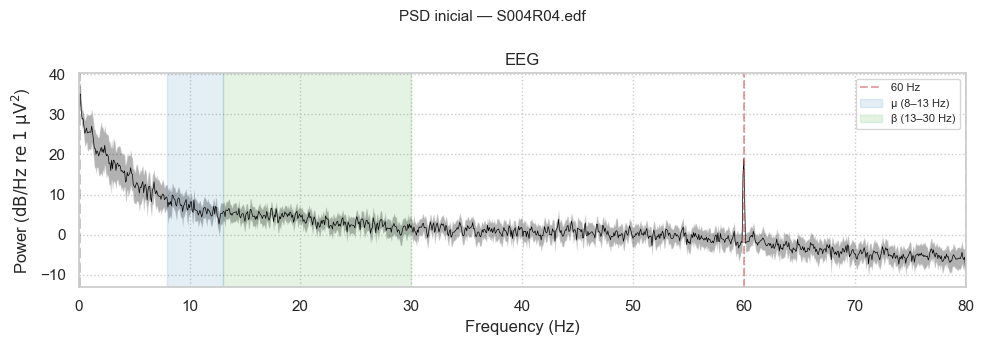

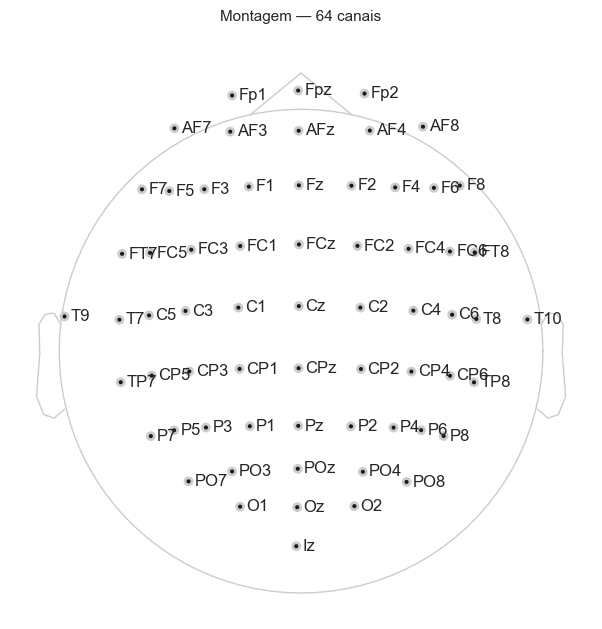

[notch] sfreq=160.0 Hz, Nyquist=80.0 Hz → aplicando em [60.0] Hz


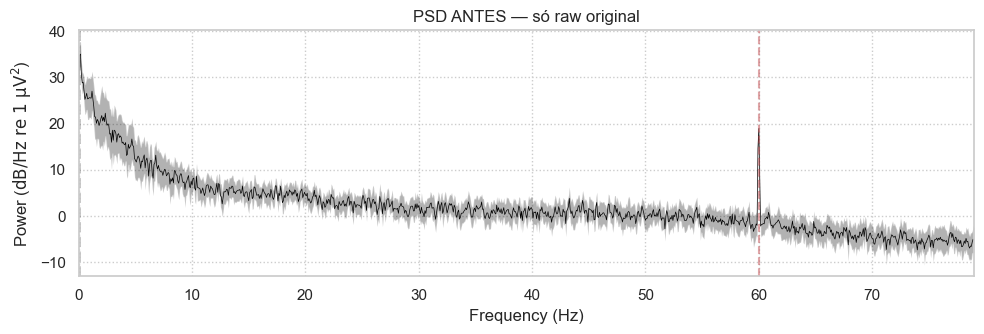

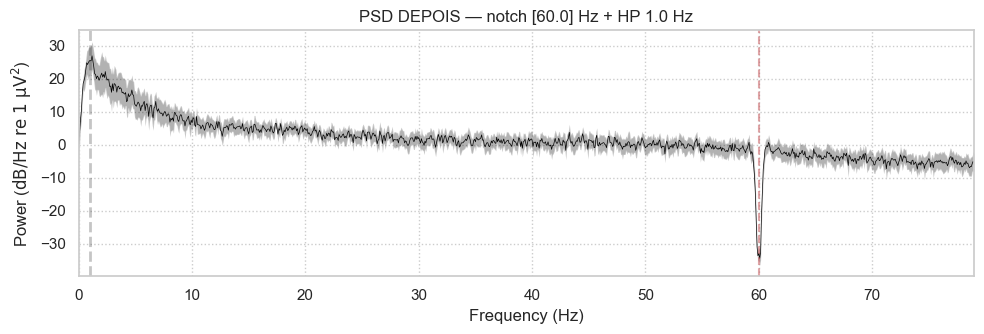

[ICA] canais=64 | rank=64 | n_components=64 | método=picard
[ICA] ajustado: 311 iterações


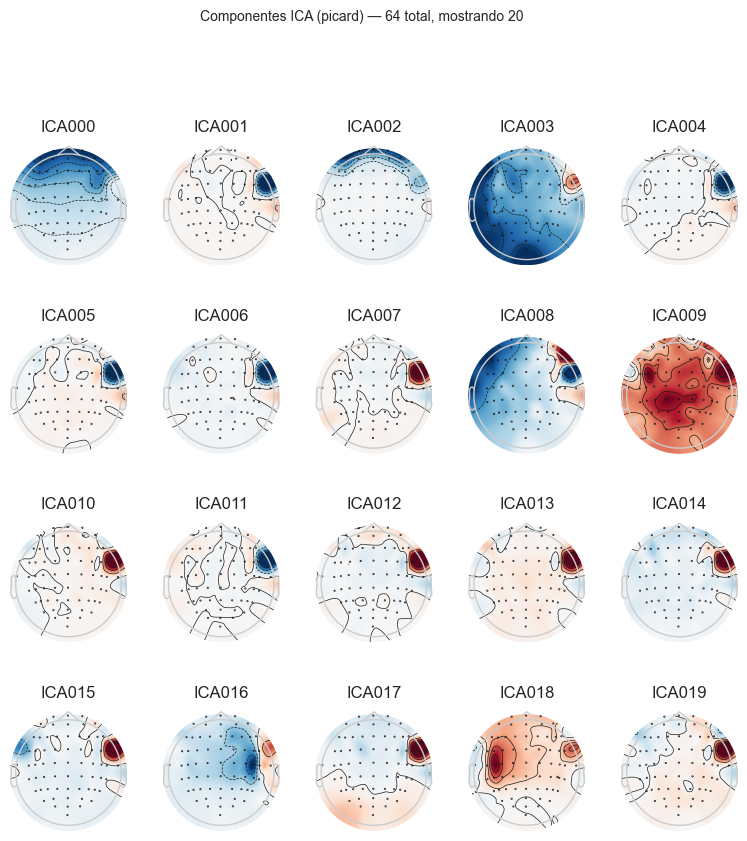


=== Classificação ICA (64 componentes) ===
  IC00 ✗ EXCLUIR  EOG(Fp1,z=-0.9)
  IC01   manter    -
  IC02 ✗ EXCLUIR  EOG(Fp1,z=-0.6)
  IC03   manter    -
  IC04   manter    -
  IC05 ✗ EXCLUIR  MUSCLE(s=0.18)
  IC06   manter    -
  IC07   manter    -
  IC08 ✗ EXCLUIR  MUSCLE(s=0.15)
  IC09   manter    -
  IC10 ✗ EXCLUIR  MUSCLE(s=0.17)
  IC11   manter    -
  IC12 ✗ EXCLUIR  MUSCLE(s=0.24)
  IC13   manter    -
  IC14 ✗ EXCLUIR  MUSCLE(s=0.16)
  IC15 ✗ EXCLUIR  MUSCLE(s=0.34)
  IC16 ✗ EXCLUIR  MUSCLE(s=0.39)
  IC17   manter    -
  IC18 ✗ EXCLUIR  MUSCLE(s=0.31)
  IC19 ✗ EXCLUIR  MUSCLE(s=0.18)
  IC20 ✗ EXCLUIR  MUSCLE(s=0.15)
  IC21   manter    -
  IC22 ✗ EXCLUIR  MUSCLE(s=0.22)
  IC23 ✗ EXCLUIR  MUSCLE(s=0.21)
  IC24   manter    -
  IC25 ✗ EXCLUIR  MUSCLE(s=0.21)
  IC26 ✗ EXCLUIR  MUSCLE(s=0.19)
  IC27   manter    -
  IC28   manter    -
  IC29   manter    -
  IC30 ✗ EXCLUIR  MUSCLE(s=0.77)
  IC31 ✗ EXCLUIR  MUSCLE(s=0.34)
  IC32 ✗ EXCLUIR  MUSCLE(s=0.16)
  IC33 ✗ EXCLUIR  MUSCLE(s=0.21)


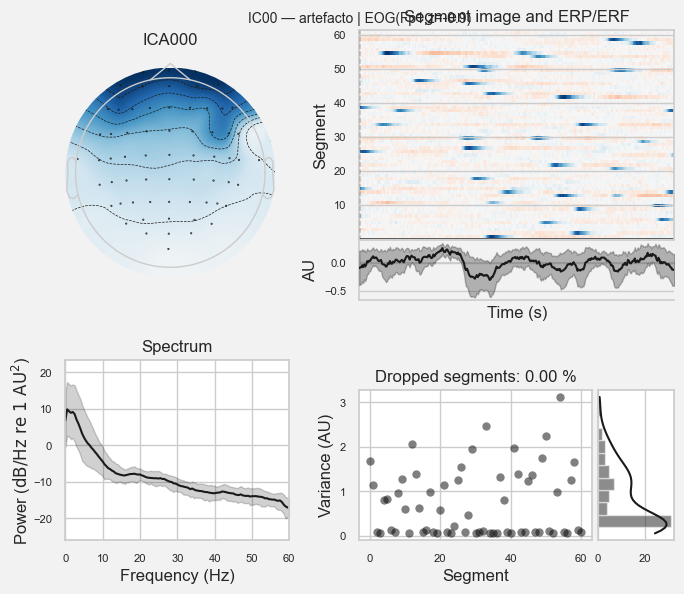


>>> IC02 — artefacto | EOG(Fp1,z=-0.6)


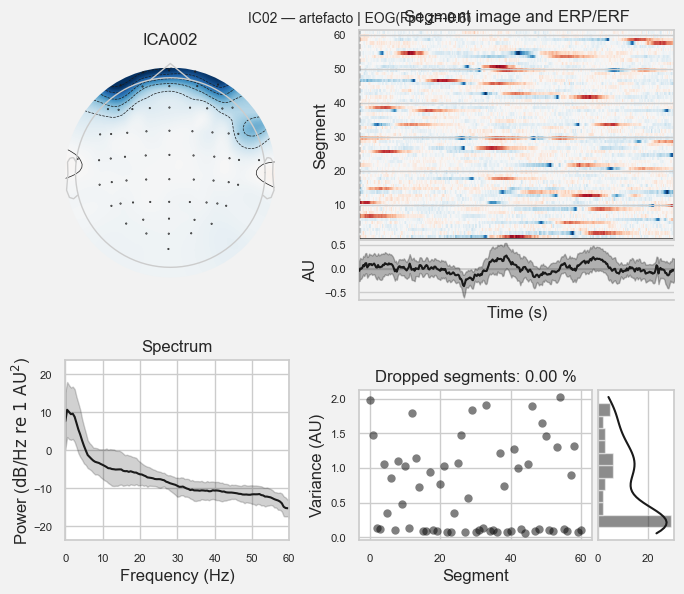


>>> IC05 — artefacto | MUSCLE(s=0.18)


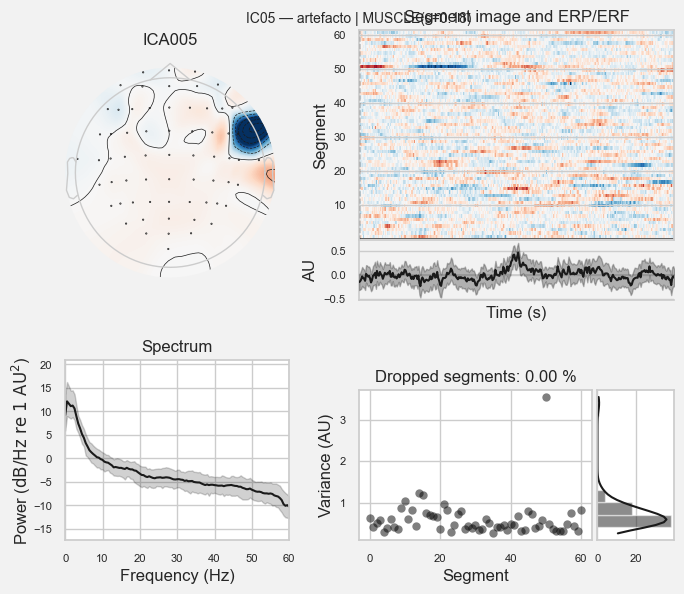


>>> IC08 — artefacto | MUSCLE(s=0.15)


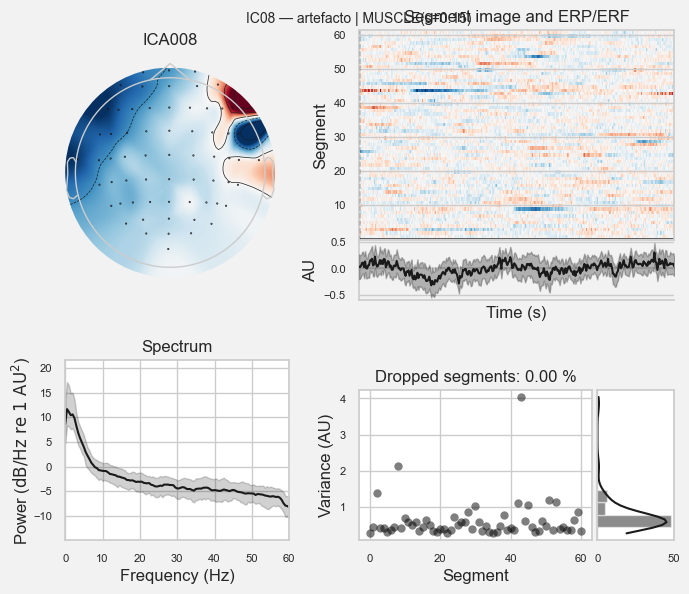


>>> IC10 — artefacto | MUSCLE(s=0.17)


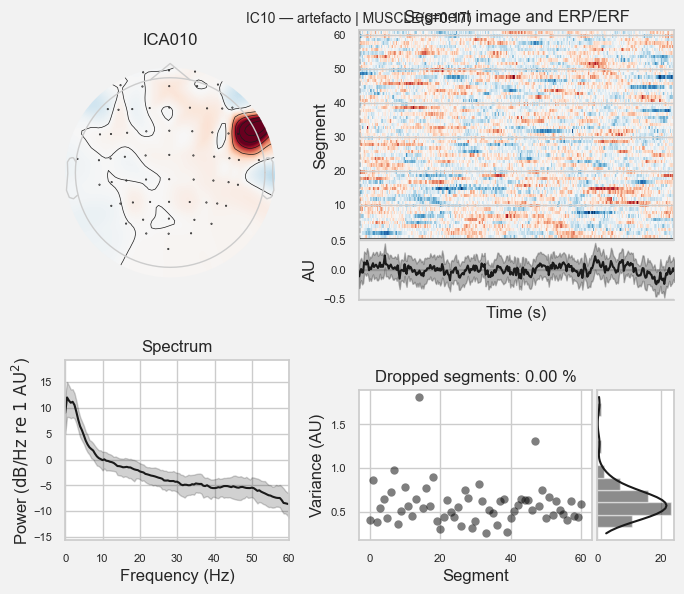


>>> IC12 — artefacto | MUSCLE(s=0.24)


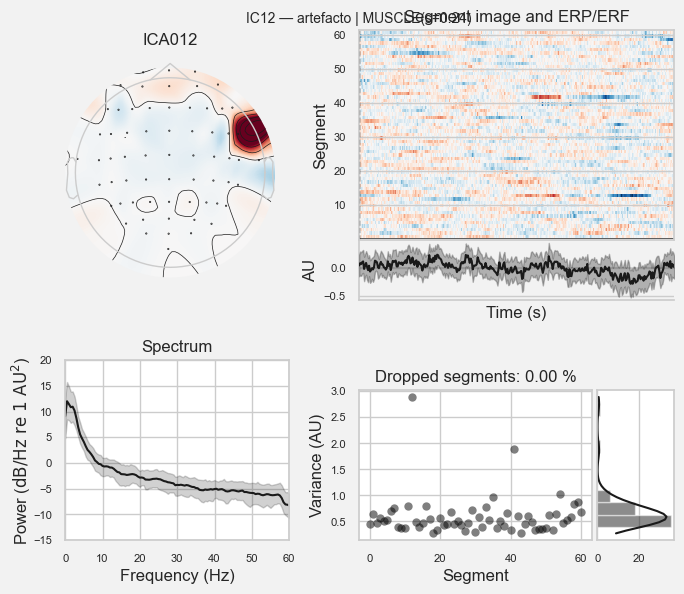


... e mais 35 componente(s) excluído(s) não plotado(s).


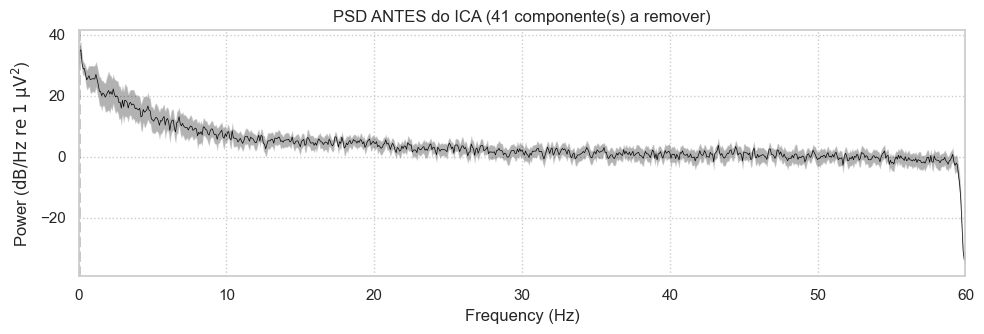

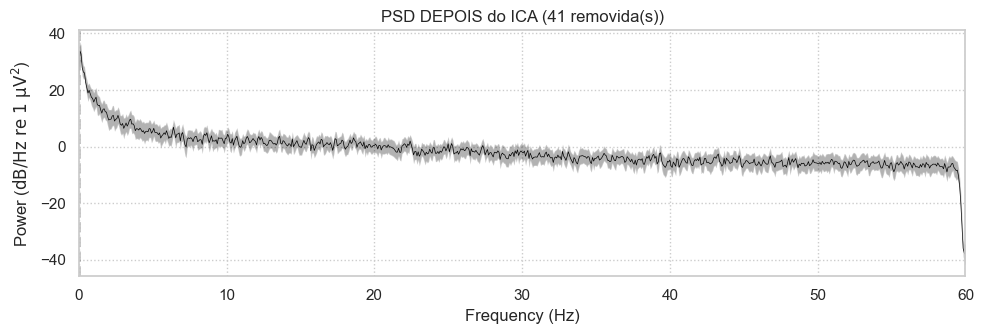

[ICA apply] removidas 41/64 componentes


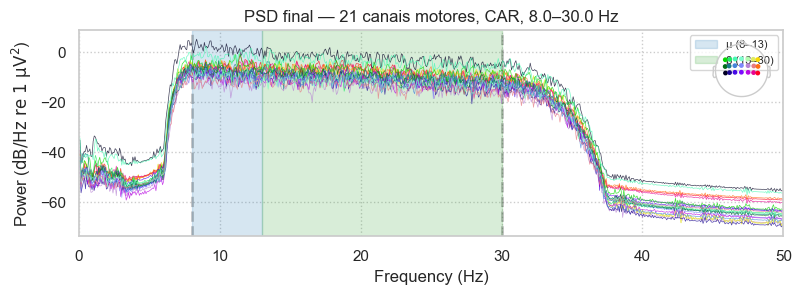

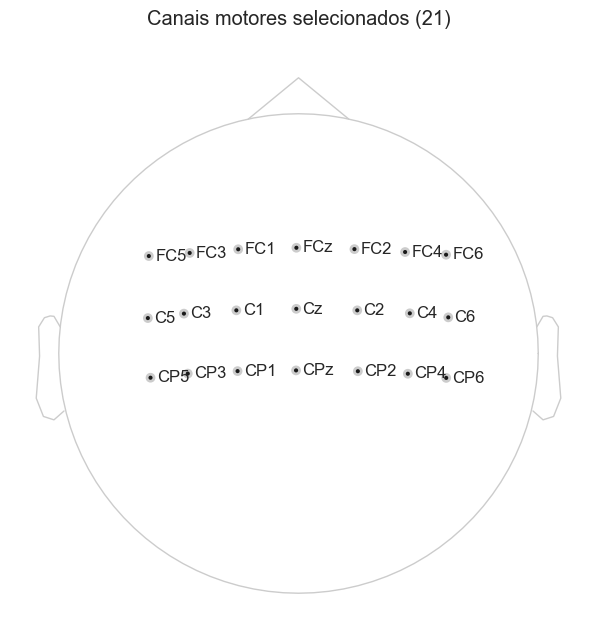

[epochs] total=15 | T1(esq)=8 | T2(dir)=7


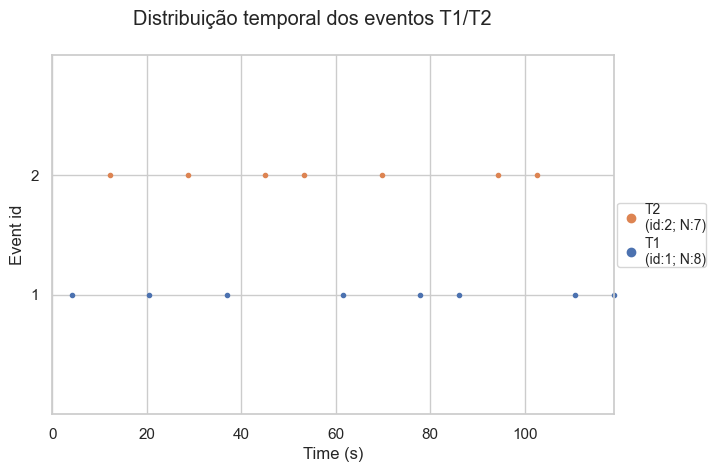

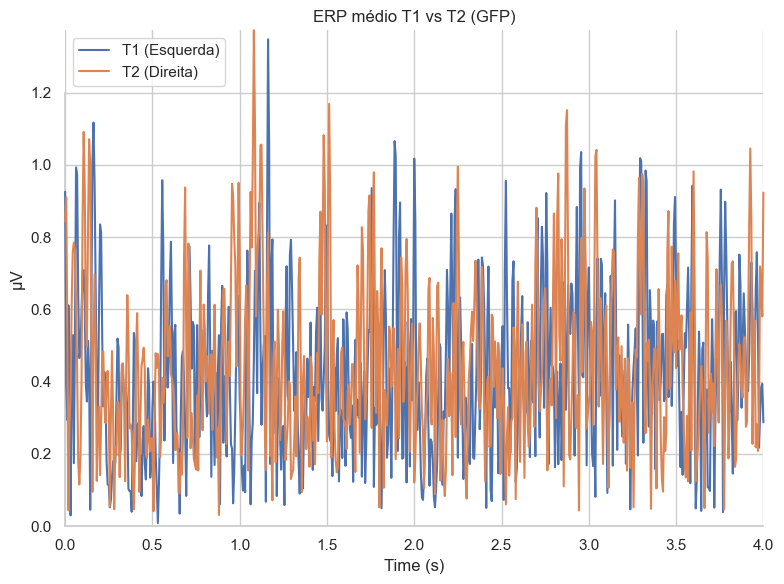

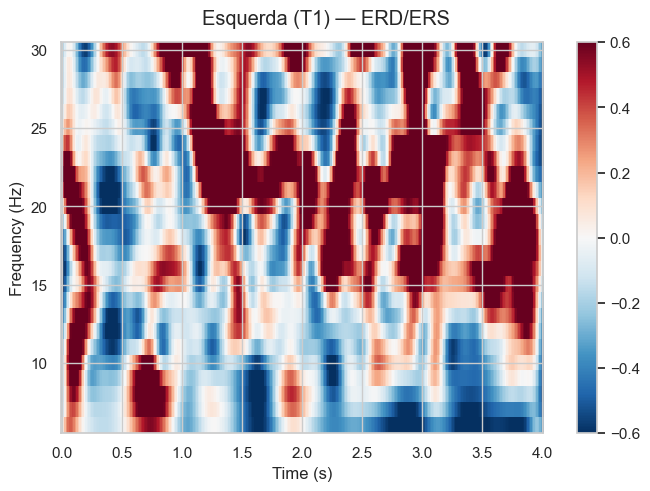

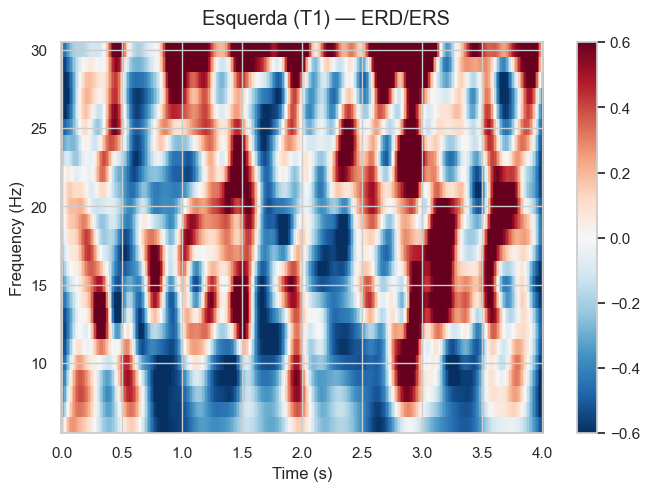

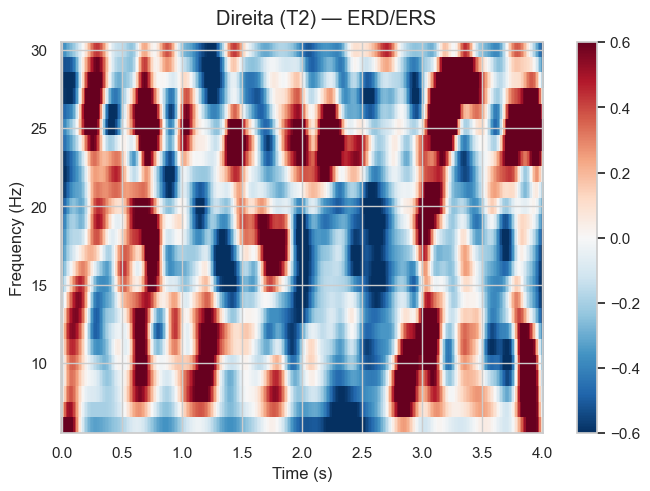

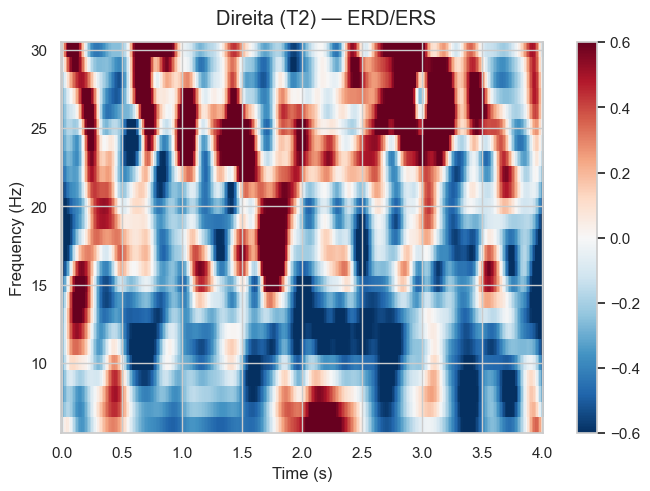


RESULTADO FINAL — S004/S004R04.edf
X shape : (15, 21, 641)   (n_épocas, n_canais, n_amostras)
y shape : (15,)
Labels  : T1 (esq) = 8 | T2 (dir) = 7
Epochs  : 15 épocas | tmin=0.0s tmax=4.0s


In [33]:
# Seleciona o primeiro arquivo de MI do primeiro sujeito e roda o pipeline completo com todas as visualizações habilitadas.
import pandas as pd
from pathlib import Path

# --- 1. Localiza os arquivos de imagética motora de mãos (R04/R08/R12) ---
caminho_csv = r"C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\eegbci_metadados_completos.csv"
df = pd.read_csv(caminho_csv, sep=';')

df_mi = df[df['Tarefa_Fisica_ou_Mental'].str.contains(
    'Imagética Motora: imaginar abrir/fechar punho', na=False
)].copy()

print(f"Total de arquivos de MI mãos: {len(df_mi)}")
print(f"Sujeitos únicos: {sorted(df_mi['Sujeito_ID'].unique())}")

# --- 2. Escolhe UM arquivo para validação visual ---
subj_test = sorted(df_mi['Sujeito_ID'].unique())[0]  # primeiro sujeito
row = df_mi[df_mi['Sujeito_ID'] == subj_test].iloc[0]  # primeiro run dele
edf_path = Path(row['Caminho_Completo'])

print(f"\n>>> Testando: sujeito {subj_test} | arquivo {edf_path.name}")

# --- 3. Roda pipeline completo com visualizações ---
epochs, X, y = preprocess_subject_run_v2(edf_path, visualize=True)

# --- 4. Sumário final ---
print("\n" + "="*60)
print(f"RESULTADO FINAL — {subj_test}/{edf_path.name}")
print("="*60)
print(f"X shape : {X.shape}   (n_épocas, n_canais, n_amostras)")
print(f"y shape : {y.shape}")
print(f"Labels  : T1 (esq) = {np.sum(y==0)} | T2 (dir) = {np.sum(y==1)}")
print(f"Epochs  : {len(epochs)} épocas | tmin={epochs.tmin}s tmax={epochs.tmax}s")

### 3.4 Aplicação em batch para todos os sujeitos

Validada a passagem única, executamos agora o pipeline completo em todos os sujeitos e runs de MI (runs 4, 8 e 12). A célula a seguir implementa:

- **Estrutura de saída em disco** em `preprocessed_v2/`, com subpastas `per_run/` (um `.fif` por arquivo processado) e `per_subject/` (um `.fif` concatenado por sujeito).
- **Pipeline retomável**: se um `.fif` já existe em `per_run/`, ele é carregado do cache em vez de reprocessado (útil para retomar após falhas).
- **Manifesto CSV** (`manifest.csv`) registrando status de cada arquivo: `ok`, `cached`, `failed`.
- **Tolerância a falhas**: arquivos com erro (EDF corrompido, eventos ausentes etc.) são logados e o batch continua.
- **Metadata por época**: cada época recebe colunas `subject`, `run` e `label`, facilitando a partição por sujeito nas tarefas seguintes.

In [ ]:
# Roda o pipeline mestre em todos os sujeitos/runs, com cache em disco, tolerância a falhas e manifest CSV de status.
import pickle
from tqdm.notebook import tqdm

#  1. Setup de diretórios 
OUTPUT_DIR = Path(r"C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "per_run").mkdir(exist_ok=True)       # 1 .fif por run
(OUTPUT_DIR / "per_subject").mkdir(exist_ok=True)   # 1 .fif concatenado por sujeito

print(f"Saída: {OUTPUT_DIR}")

# 2. Runs de MI mãos, organizados por sujeito 
df_mi = df[df['Tarefa_Fisica_ou_Mental'].str.contains(
    'Imagética Motora: imaginar abrir/fechar punho', na=False
)].copy()
df_mi = df_mi.sort_values(['Sujeito_ID', 'Nome_do_Arquivo'])
subjects = sorted(df_mi['Sujeito_ID'].unique())

# Extrai número do run do nome do arquivo (ex: S001R04.edf → 4)
df_mi['run_number'] = df_mi['Nome_do_Arquivo'].str.extract(r'R(\d+)').astype(int)

print(f"Processando {len(subjects)} sujeitos, {len(df_mi)} arquivos no total\n")

# 3. Loop principal 
manifest = []      # log de sucesso/falha por arquivo
failed   = []

for subj in tqdm(subjects, desc="Sujeitos"):
    sub_rows = df_mi[df_mi['Sujeito_ID'] == subj]
    epochs_list = []   # vai concatenar depois

    for _, row in sub_rows.iterrows():
        run_num = int(row['run_number'])
        edf_path = Path(row['Caminho_Completo'])
        out_fif = OUTPUT_DIR / "per_run" / f"{subj}_R{run_num:02d}-epo.fif"

        # Skip se já existe (pipeline retomável)
        if out_fif.exists():
            try:
                ep = mne.read_epochs(out_fif, preload=True, verbose=False)
                epochs_list.append(ep)
                manifest.append({'subject': subj, 'run': run_num,
                                 'status': 'cached', 'n_epochs': len(ep),
                                 'file': str(out_fif)})
                continue
            except Exception:
                pass  # cache corrompido → reprocessa

        # Processa
        try:
            ep, X, y = preprocess_subject_run_v2(edf_path, visualize=False)

            # Adiciona metadata: sujeito e run
            ep.metadata = pd.DataFrame({
                'subject': [subj] * len(ep),
                'run'    : [run_num] * len(ep),
                'label'  : ['T1' if c == 1 else 'T2' for c in ep.events[:, 2]],
            })

            ep.save(out_fif, overwrite=True, verbose=False)
            epochs_list.append(ep)
            manifest.append({'subject': subj, 'run': run_num,
                             'status': 'ok', 'n_epochs': len(ep),
                             'file': str(out_fif)})

        except Exception as e:
            msg = f"{type(e).__name__}: {e}"
            print(f"  [ERRO] {subj}/R{run_num:02d}: {msg}")
            failed.append({'subject': subj, 'run': run_num, 'error': msg,
                           'file': str(edf_path)})
            manifest.append({'subject': subj, 'run': run_num,
                             'status': 'failed', 'n_epochs': 0,
                             'file': str(edf_path)})

    # Concatena runs deste sujeito num único arquivo
    if epochs_list:
        try:
            ep_cat = mne.concatenate_epochs(epochs_list, verbose=False)
            out_cat = OUTPUT_DIR / "per_subject" / f"{subj}_allruns-epo.fif"
            ep_cat.save(out_cat, overwrite=True, verbose=False)
            print(f"  {subj}: {len(ep_cat)} épocas concatenadas "
                  f"→ {out_cat.name}")
        except Exception as e:
            print(f"  [concat erro] {subj}: {e}")

# 4. Salva manifest e resumo 
df_manifest = pd.DataFrame(manifest)
df_manifest.to_csv(OUTPUT_DIR / "manifest.csv", sep=';', index=False)

print("\n" + "="*60)
print("BATCH CONCLUÍDO")
print("="*60)
print(df_manifest.groupby('status').size())
if failed:
    print(f"\n{len(failed)} falha(s):")
    for f in failed:
        print(f"  - {f['subject']}/R{f['run']:02d}: {f['error']}")
print(f"\nArquivos em: {OUTPUT_DIR}")

Saída: C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2
Processando 10 sujeitos, 30 arquivos no total



Sujeitos:   0%|          | 0/10 [00:00<?, ?it/s]

  S004: 45 épocas concatenadas → S004_allruns-epo.fif
  S014: 45 épocas concatenadas → S014_allruns-epo.fif
  S015: 45 épocas concatenadas → S015_allruns-epo.fif
  S018: 45 épocas concatenadas → S018_allruns-epo.fif
  S029: 45 épocas concatenadas → S029_allruns-epo.fif
  S032: 45 épocas concatenadas → S032_allruns-epo.fif
  S036: 45 épocas concatenadas → S036_allruns-epo.fif
  S082: 45 épocas concatenadas → S082_allruns-epo.fif
  S087: 45 épocas concatenadas → S087_allruns-epo.fif
  S095: 45 épocas concatenadas → S095_allruns-epo.fif

BATCH CONCLUÍDO
status
cached    30
dtype: int64

Arquivos em: C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2


### 3.5 Carregamento consolidado e validação do ICA

Com todos os arquivos pré-processados em disco, precisamos de duas coisas para as próximas tarefas:

1. Uma função utilitária (`load_all_subjects`) que lê todos os `.fif` concatenados por sujeito e monta os arrays unificados `X` (épocas × canais × tempo), `y` (labels) e `groups` (identificador do sujeito, essencial para GroupKFold).
2. Uma checagem heurística de que o ICA realmente foi aplicado, já que um erro silencioso no batch poderia deixar arquivos sem limpeza. Usamos a amplitude pico-a-pico em um canal frontal: se muitas épocas excedem 100 µV, há forte indício de piscadas residuais, logo o ICA não foi efetivo.

In [36]:
# Função utilitária: carrega todos os .fif concatenados por sujeito e retorna X, y, groups e runs unificados.
def load_all_subjects(output_dir=OUTPUT_DIR):
    fif_files = sorted((output_dir / "per_subject").glob("*_allruns-epo.fif"))
    print(f"Carregando {len(fif_files)} sujeitos...")

    X_list, y_list, groups_list, runs_list = [], [], [], []
    for fp in fif_files:
        ep = mne.read_epochs(fp, preload=True, verbose=False)
        X_sub = ep.get_data()
        y_sub = np.array([0 if c == 1 else 1 for c in ep.events[:, 2]])
        subj = ep.metadata['subject'].values
        runs = ep.metadata['run'].values

        X_list.append(X_sub)
        y_list.append(y_sub)
        groups_list.append(subj)
        runs_list.append(runs)

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list)
    groups = np.concatenate(groups_list)
    runs = np.concatenate(runs_list)

    print(f"Total: X={X.shape}, y={y.shape}")
    print(f"Sujeitos: {len(np.unique(groups))} | "
          f"Épocas por sujeito: {np.bincount(pd.factorize(groups)[0])}")
    print(f"Balance: T1={np.sum(y==0)}, T2={np.sum(y==1)}")
    return X, y, groups, runs

In [37]:
# Executa o carregamento consolidado, produzindo os arrays X, y, groups e runs usados nas próximas tarefas.
X, y, groups, runs = load_all_subjects(OUTPUT_DIR)

Carregando 10 sujeitos...
Total: X=(450, 15, 673), y=(450,)
Sujeitos: 10 | Épocas por sujeito: [45 45 45 45 45 45 45 45 45 45]
Balance: T1=225, T2=225


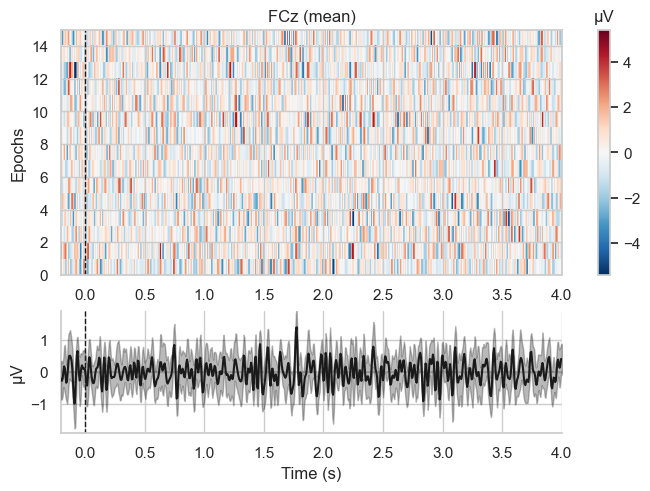

[<Figure size 640x480 with 3 Axes>]

In [38]:
# Inspeção visual rápida: plota a média das épocas no canal FCz para um run pré-processado, como conferência final.
import mne

# Carrega um arquivo de run (pré-processado)
ep = mne.read_epochs(OUTPUT_DIR / "per_run" / "S004_R04-epo.fif", preload=True)

# Plota a média das épocas para o canal FCz
ep.plot_image(picks='FCz', combine='mean', show=True)

In [39]:
# Checagem heurística de que o ICA foi aplicado: mede amplitude pico-a-pico em canal frontal e alerta se piscadas persistirem.
import mne
import numpy as np
from pathlib import Path

def check_ica_applied(epochs_path, ch_name='FCz', amp_thresh=100e-6, ratio_thresh=0.15):
    """
    Verifica indícios de que o ICA foi aplicado nas épocas.

    Heurística usada:
      - Para cada época, mede a amplitude pico‑a‑pico em 'ch_name'.
      - Se mais de `ratio_thresh` (e.g., 15%) das épocas exceder
        `amp_thresh` (100 µV), provavelmente há piscadas/movimentos
        oculares ainda presentes → ICA NÃO foi aplicado (ou foi insuficiente).
      - Caso contrário, assume‑se que o sinal está mais limpo → ICA aplicado.

    Parâmetros
    ----------
    epochs_path : str | Path
        Caminho do arquivo -epo.fif.
    ch_name : str
        Canal frontal usado para detetar piscadas (ex.: 'FCz', 'FC1').
    amp_thresh : float
        Limiar de amplitude pico‑a‑pico (em Volts).  100e-6 = 100 µV.
    ratio_thresh : float
        Proporção máxima de épocas que podem exceder o limiar para ainda
        considerarmos "sem artefactos oculares".

    Retorna
    -------
    ica_likely : bool
        True se o ICA parece ter sido aplicado, False caso contrário.
    artifacts_ratio : float
        Proporção de épocas que ultrapassaram o limiar.
    """
    epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)
    
    if ch_name not in epochs.ch_names:
        print(f"[check_ica] Canal {ch_name} não encontrado. Canais disponíveis: {epochs.ch_names}")
        return None, None
    
    # Seleciona o canal de interesse
    data = epochs.get_data(picks=ch_name)   # shape: (n_epochs, 1, n_times)
    data = data[:, 0, :]                    # fica (n_epochs, n_times)
    
    # Amplitude pico‑a‑pico em cada época
    ptp = np.ptp(data, axis=1)  # max - min ao longo do tempo
    
    artifacts_ratio = np.mean(ptp > amp_thresh)
    
    ica_likely = artifacts_ratio < ratio_thresh
    
    print(f"[check_ica] Arquivo      : {Path(epochs_path).name}")
    print(f"          Canal usado   : {ch_name}")
    print(f"          Épocas totais  : {len(ptp)}")
    print(f"          Épocas >{amp_thresh*1e6:.0f} µV: {np.sum(ptp > amp_thresh)} ({artifacts_ratio:.1%})")
    print(f"          Conclusão      : {'ICA provavelmente APLICADO' if ica_likely else 'Artefactos ainda presentes → ICA NÃO aplicado ou insuficiente'}")
    
    return ica_likely, artifacts_ratio


# Exemplo de uso para um sujeito (run individual)
# check_ica_applied(OUTPUT_DIR / "per_run" / "S004_R04-epo.fif")

# Verificar todos os runs de um sujeito:
for run in (4,8,12):
     fname = OUTPUT_DIR / "per_run" / f"S004_R{run:02d}-epo.fif"
     check_ica_applied(fname)

[check_ica] Arquivo      : S004_R04-epo.fif
          Canal usado   : FCz
          Épocas totais  : 15
          Épocas >100 µV: 0 (0.0%)
          Conclusão      : ICA provavelmente APLICADO
[check_ica] Arquivo      : S004_R08-epo.fif
          Canal usado   : FCz
          Épocas totais  : 15
          Épocas >100 µV: 0 (0.0%)
          Conclusão      : ICA provavelmente APLICADO
[check_ica] Arquivo      : S004_R12-epo.fif
          Canal usado   : FCz
          Épocas totais  : 15
          Épocas >100 µV: 0 (0.0%)
          Conclusão      : ICA provavelmente APLICADO


## 4. Tarefa 2 - Construção das Representações

Com as épocas pré-processadas, construímos duas representações complementares dos dados, adequadas a famílias distintas de modelos:

### 4.1 Representação clássica (features tabulares)

Para cada época e cada canal motor, calculamos um conjunto de features neurofisiologicamente interpretáveis:

- **Potência relativa por banda** mu (8–13 Hz), beta baixo (13–20 Hz) e beta alto (20–30 Hz) computada via Welch e normalizada pela soma das três, de modo a obter proporções independentes de escala.
- **Variância** do sinal no tempo (proxy de energia).
- **Parâmetros de Hjorth** - **Mobility** (proporcional à frequência dominante) e **Complexity** (desvio do sinal em relação a uma senóide pura). Activity de Hjorth é idêntica à variância e foi omitida para evitar redundância.
- **Entropia espectral** de Shannon sobre a PSD normalizada (mede o quão "plana" está a distribuição espectral).

O resultado é um vetor por época de dimensão `n_canais × n_features_por_canal`, pronto para classificadores tabulares (LDA, SVM, Random Forest, XGBoost).

### 4.2 Representação temporal

Para modelos que aprendem filtros do próprio sinal (CNN 1D/2D, EEGNet), a entrada mais natural é o próprio sinal pré-processado em formato 3D `(n_épocas, n_canais, n_amostras)`. Aqui fazemos apenas uma cópia explícita de `X`, deixando a representação pronta para ser usada em tarefas de Deep Learning.

In [ ]:
# Extrai features clássicas por época e canal: potências relativas de banda (mu/beta_low/beta_high), variância, Hjorth (Mobility, Complexity) e entropia espectral.
# FEATURES CLÁSSICAS
import numpy as np
from scipy import signal as sp_signal
from scipy.stats import entropy as scipy_entropy
import mne
from pathlib import Path
from scipy.integrate import trapezoid 


# 1. Obter sfreq de forma robusta (a partir de um arquivo .fif)

# Aponte para o diretório onde estão os dados pré‑processados
OUTPUT_DIR = Path(r"C:\Users\tiago\Downloads\Mini_Projeto_2_Tiago\data_eegmmidb\preprocessed_v2")
fif_exemplo = OUTPUT_DIR / "per_subject" / "S004_allruns-epo.fif"
ep_tmp = mne.read_epochs(fif_exemplo, preload=True, verbose=False)
SFREQ = ep_tmp.info['sfreq']

# 2. Definição das bandas

BANDS = {
    'mu':        (8, 13),
    'beta_low':  (13, 20),
    'beta_high': (20, 30),
}

# 3. Funções de extração 

def bandpower_welch(sig, sfreq, fmin, fmax):
    """Potência absoluta via Welch numa banda [fmin, fmax]."""
    freqs, psd = sp_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    mask = (freqs >= fmin) & (freqs <= fmax)
    return trapezoid(psd[mask], freqs[mask])   # substitui np.trapz

def hjorth_params(sig):
    """Retorna Activity, Mobility, Complexity de Hjorth."""
    activity = np.var(sig)
    d1 = np.diff(sig)
    d2 = np.diff(d1)
    var_d1 = np.var(d1)
    var_d2 = np.var(d2)
    mobility = np.sqrt(var_d1 / (activity + 1e-12))
    complexity = np.sqrt(var_d2 / (var_d1 + 1e-12)) / (mobility + 1e-12)
    return activity, mobility, complexity

def spectral_entropy(sig, sfreq):
    """Entropia de Shannon da PSD normalizada."""
    freqs, psd = sp_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
    psd_norm = psd / (psd.sum() + 1e-12)
    return scipy_entropy(psd_norm)

def extract_classical_features(X, sfreq=SFREQ, bands=BANDS):
    """
    X: (n_epochs, n_channels, n_times)
    Retorna: (n_epochs, n_features), feature_names
    """
    n_epochs, n_ch, n_t = X.shape
    feats_per_ep = []
    feat_names = None

    for ep in X:
        row = []
        names = []
        for ci in range(n_ch):
            sig = ep[ci]

            # Band powers
            bps = {}
            for bname, (fl, fh) in bands.items():
                bps[bname] = bandpower_welch(sig, sfreq, fl, fh)
            total = sum(bps.values()) + 1e-12
            for bname, v in bps.items():
                row.append(v / total)          # potência relativa
                names.append(f"ch{ci}_relpow_{bname}")

            # Variância
            row.append(np.var(sig))
            names.append(f"ch{ci}_var")

            # Hjorth
            act, mob, comp = hjorth_params(sig)
            row.extend([mob, comp])            # activity já é var → redundante
            names.extend([f"ch{ci}_hjorth_mob", f"ch{ci}_hjorth_comp"])

            # Entropia espectral
            row.append(spectral_entropy(sig, sfreq))
            names.append(f"ch{ci}_spec_entropy")

        feats_per_ep.append(row)
        if feat_names is None:
            feat_names = names

    return np.array(feats_per_ep), feat_names

# 4. Extração das features (usa o X já carregado no ambiente)

# Garanta que X seja o array 3D (épocas, canais, tempos)
# Se o seu array se chama X_epochs, troque abaixo
if 'X' not in dir():
    raise RuntimeError("Array 'X' não encontrado. Execute load_all_subjects() primeiro.")

print("Extraindo features clássicas…")
X_feat, feat_names = extract_classical_features(X)
print(f"Shape: {X_feat.shape}  ({len(feat_names)} features)")
print(f"Features por canal: {len(feat_names) // X.shape[1]}")

Extraindo features clássicas…
Shape: (450, 105)  (105 features)
Features por canal: 7


In [ ]:
# Representação temporal: mantém o sinal pré-processado em formato 3D (épocas, canais, tempo), pronto para CNNs.
# REPRESENTAÇÃO TEMPORAL 
# Mantém o sinal bruto (já pré-processado) input para CNN
X_temporal = X.copy()
print(f"Representação temporal: {X_temporal.shape}")
print(f"  n_epochs = {X_temporal.shape[0]}")
print(f"  n_channels = {X_temporal.shape[1]}")
print(f"  n_timepoints = {X_temporal.shape[2]}  (={X_temporal.shape[2]/SFREQ:.1f} s {SFREQ} Hz)")


Representação temporal: (450, 15, 673)
  n_epochs = 450
  n_channels = 15
  n_timepoints = 673  (=4.2 s 160.0 Hz)


### 4.3 Visualização comparativa das representações

Para dar intuição sobre o que cada representação carrega, a célula a seguir gera um painel duplo:

- **Esquerda:** histograma da feature `ch0_relpow_mu` (potência relativa na banda mu no primeiro canal motor), separado por classe. É uma visão da representação clássica, mostra o quanto uma única feature já discrimina (ou não) mão esquerda vs. direita.
- **Direita:** média do sinal temporal em C3 para cada classe ao longo dos 4 segundos da época. Aqui vemos a forma de onda média, uma pista visual direta para modelos que operam no tempo.

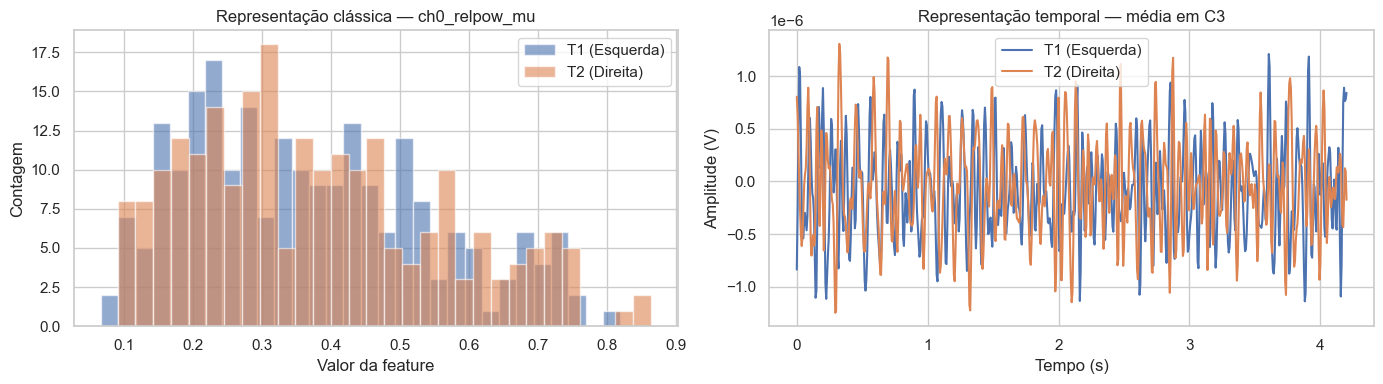

In [42]:
# Plota lado a lado: histograma de uma feature clássica por classe + média temporal em C3 por classe, para comparar as duas representações.
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (1) Distribuição de uma feature clássica
ex_feat_idx = feat_names.index("ch0_relpow_mu") if "ch0_relpow_mu" in feat_names else 0
for lab, name in LABEL_NAMES.items():
    axes[0].hist(X_feat[y == lab, ex_feat_idx], bins=30, alpha=0.6, label=name)
axes[0].set_title(f"Representação clássica — {feat_names[ex_feat_idx]}")
axes[0].set_xlabel("Valor da feature")
axes[0].set_ylabel("Contagem")
axes[0].legend()

# (2) Média do sinal temporal em C3
# Obtém os nomes dos canais a partir do arquivo de exemplo carregado antes (ep_tmp)
ch_names = ep_tmp.ch_names   # ou use ep_tmp.info['ch_names'] se preferir
if 'C3' in ch_names:
    c3_idx = ch_names.index('C3')
    t = np.arange(X_temporal.shape[2]) / SFREQ   # SFREQ já definida na célula de features
    for lab, name in LABEL_NAMES.items():
        axes[1].plot(t, X_temporal[y == lab, c3_idx, :].mean(axis=0), label=name)
    axes[1].set_title("Representação temporal — média em C3")
    axes[1].set_xlabel("Tempo (s)")
    axes[1].set_ylabel("Amplitude (V)")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'C3 não encontrado', ha='center', va='center')
    axes[1].set_title("C3 indisponível")

plt.tight_layout()
plt.show()

## 5. Tarefa 3 - Redução de Dimensionalidade

**Objetivo:** reduzir o número de variáveis (105 features clássicas) para um espaço de menor dimensão, com o intuito de eliminar redundâncias, facilitar a visualização e, idealmente, melhorar a estabilidade dos modelos de classificação. Todos os resultados de performance foram obtidos com validação cruzada que respeita os sujeitos (GroupKFold, 5 splits), utilizando pipelines do `scikit-learn` para impedir vazamento de dados entre treino e teste.

### Técnicas utilizadas

- **PCA:** Análise de Componentes Principais (não supervisionada). Cria componentes que capturam a máxima variância dos dados, sem usar os rótulos das classes.
- **LDA:** Análise Discriminante Linear (supervisionada). Encontra a direção que maximiza a separação entre mão esquerda e mão direita.
- **t-SNE:** apenas para visualização exploratória (não pode ser usada em pipelines de classificação, pois não possui `transform` para novos dados).
- **SelectKBest:** seleção supervisionada das *k* features com maior score ANOVA. Representa uma redução de dimensionalidade que preserva as variáveis originais.

### 5.1 Visualização exploratória (fit global apenas para inspeção)

Nesta primeira célula, os redutores de dimensionalidade são ajustados no dataset inteiro (nos 10 sujeitos), o que é aceitável apenas para visualização, mas não para estimar performance. 

- Scatter PCA 2D, com os percentuais de variância explicada nos eixos.
- Histograma LDA 1D (projeção supervisionada).
- Scatter t-SNE 2D (estrutura local não-linear).
- Curva de variância acumulada da PCA, com destaque para quantos componentes são necessários para atingir 95% da variância.

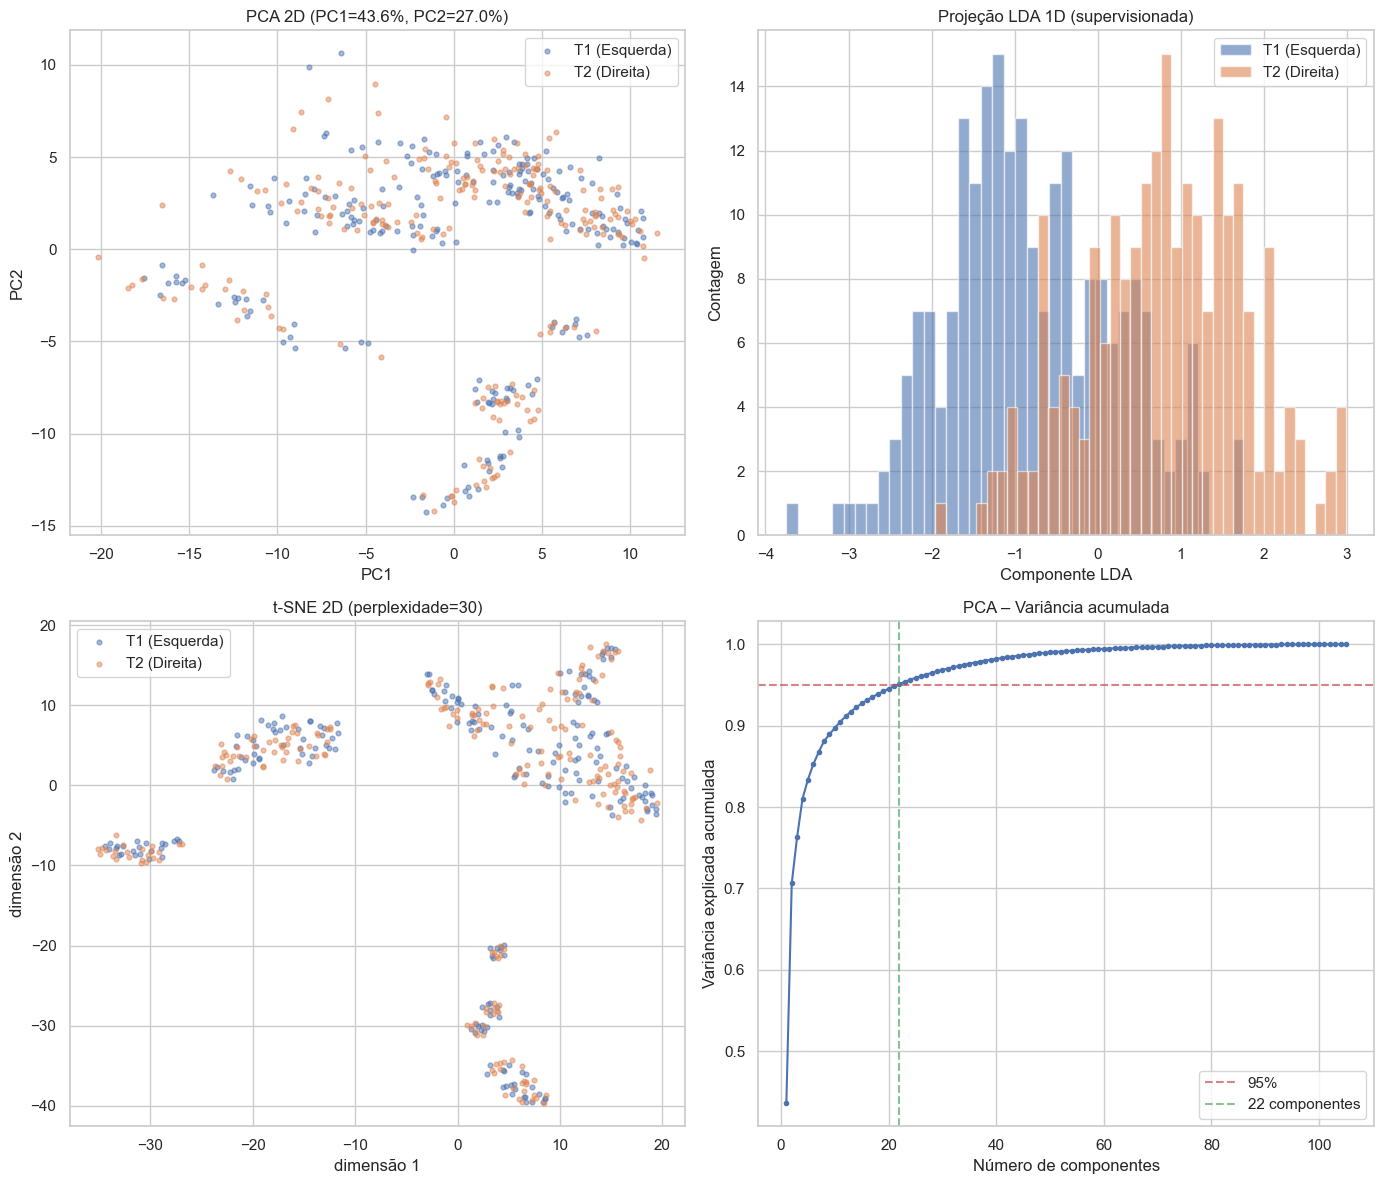

Componentes para explicar 95% da variância: 22 (de 105)


In [ ]:
# Visualização exploratória (fit global, SÓ PARA INSPEÇÃO — não é CV): PCA 2D, LDA 1D, t-SNE 2D e curva de variância acumulada.
#  VISUALIZAÇÃO EXPLORATÓRIA 
# AVISO: este fit global serve apenas para plotar. NÃO use para avaliar modelos.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

SEED = 42

# Padronização
scaler_viz = StandardScaler().fit(X_feat)
X_std = scaler_viz.transform(X_feat)

# --- PCA (2 componentes para visualização) ---
pca_2d = PCA(n_components=2, random_state=SEED).fit(X_std)
X_pca = pca_2d.transform(X_std)

# --- LDA (1 componente para visualização) ---
lda = LinearDiscriminantAnalysis(n_components=1).fit(X_std, y)
X_lda = lda.transform(X_std)

# --- t-SNE (2 componentes, apenas visual) ---
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_std)

# PLOTS 
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. PCA scatter
for lab, name in LABEL_NAMES.items():
    mask = y == lab
    axes[0,0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, label=name, s=12)
axes[0,0].set_title(
    f"PCA 2D (PC1={pca_2d.explained_variance_ratio_[0]:.1%}, "
    f"PC2={pca_2d.explained_variance_ratio_[1]:.1%})"
)
axes[0,0].set_xlabel("PC1"); axes[0,0].set_ylabel("PC2")
axes[0,0].legend()

# 2. LDA 1D histograma
for lab, name in LABEL_NAMES.items():
    axes[0,1].hist(X_lda[y == lab, 0], bins=40, alpha=0.6, label=name)
axes[0,1].set_title("Projeção LDA 1D (supervisionada)")
axes[0,1].set_xlabel("Componente LDA"); axes[0,1].set_ylabel("Contagem")
axes[0,1].legend()

# 3. t-SNE scatter
for lab, name in LABEL_NAMES.items():
    mask = y == lab
    axes[1,0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.5, label=name, s=12)
axes[1,0].set_title("t-SNE 2D (perplexidade=30)")
axes[1,0].set_xlabel("dimensão 1"); axes[1,0].set_ylabel("dimensão 2")
axes[1,0].legend()

# 4. Variância explicada cumulativa PCA
pca_full = PCA().fit(X_std)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1
axes[1,1].plot(range(1, len(cum_var)+1), cum_var, marker='o', ms=3)
axes[1,1].axhline(0.95, color='r', linestyle='--', alpha=0.7, label='95%')
axes[1,1].axvline(n_95, color='g', linestyle='--', alpha=0.7, label=f'{n_95} componentes')
axes[1,1].set_xlabel("Número de componentes")
axes[1,1].set_ylabel("Variância explicada acumulada")
axes[1,1].set_title("PCA – Variância acumulada")
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()
print(f"Componentes para explicar 95% da variância: {n_95} (de {X_std.shape[1]})")

### 5.2 Avaliação com validação cruzada (GroupKFold)

Aqui  avaliamos de forma inicial o impacto das diferentes estratégias de redução de dimensionalidade, usando `Pipeline` do `scikit-learn` (que encapsula padronização + redução + classificador e garante que tudo é ajustado só no treino de cada fold) e `GroupKFold` (que isola sujeitos inteiros em cada partição).

Cinco estratégias são comparadas:

1. **LDA puro** nas 105 features originais - baseline.
2. **PCA(22) + LDA:**  reduz para 22 componentes (95% da variância) antes de discriminar.
3. **PCA(22) + SVM linear:**  mesma redução, classificador diferente.
4. **LDA(1) + SVM linear:** LDA como redutor para 1 dimensão e SVM por cima.
5. **SelectKBest(50) + SVM linear:** seleção supervisionada das 50 melhores features + SVM.

In [ ]:
# Compara cinco estratégias de redução/seleção (LDA, PCA+LDA, PCA+SVM, LDA+SVM, SelectKBest+SVM) com GroupKFold=5, usando pipelines para evitar vazamento.

# AVALIAÇÃO COM VALIDAÇÃO CRUZADA (KFOLD)
# Aqui comparamos o impacto de diferentes técnicas de redução de dimensionalidade
# na performance de classificadores. Tudo é feito dentro de pipelines para evitar
# vazamento de dados.

from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import numpy as np

# Validação cruzada que respeita os sujeitos
gkf = GroupKFold(n_splits=5)

# 1. Baseline: LDA puro (sem redução prévia) 
lda = LDA()
scores_lda = cross_val_score(lda, X_feat, y, groups=groups, cv=gkf, scoring='accuracy')

# 2. PCA + LDA 
# Número de componentes escolhido exploratoriamente (ex.: 22 para 95% de variância)
n_comp = 22
pipe_pca_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_comp)),
    ('lda', LDA())
])
scores_pca_lda = cross_val_score(pipe_pca_lda, X_feat, y, groups=groups, cv=gkf, scoring='accuracy')

# 3. PCA + SVM linear (para verificar com outro classificador) 
pipe_pca_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_comp)),
    ('svm', SVC(kernel='linear'))
])
scores_pca_svm = cross_val_score(pipe_pca_svm, X_feat, y, groups=groups, cv=gkf, scoring='accuracy')

# 4. LDA como redutor + SVM (técnica mista) 
# O LDA reduz para 1 componente e depois um SVM classifica sobre essa projeção.
pipe_lda_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LDA(n_components=1)),
    ('svm', SVC(kernel='linear'))
])
scores_lda_svm = cross_val_score(pipe_lda_svm, X_feat, y, groups=groups, cv=gkf, scoring='accuracy')

# 5. Seleção de features com SelectKBest (supervisionada) + SVM 
from sklearn.feature_selection import SelectKBest, f_classif
k = 50
pipe_kbest_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_classif, k=k)),
    ('svm', SVC(kernel='linear'))
])
scores_kbest_svm = cross_val_score(pipe_kbest_svm, X_feat, y, groups=groups, cv=gkf, scoring='accuracy')

# Exibição dos resultados 
print("Acurácias médias (GroupKFold 5 splits) ± desvio padrão:\n")
print(f"LDA puro (105 features)              : {scores_lda.mean():.2%} ± {scores_lda.std():.2%}")
print(f"PCA({n_comp}) + LDA                    : {scores_pca_lda.mean():.2%} ± {scores_pca_lda.std():.2%}")
print(f"PCA({n_comp}) + SVM linear             : {scores_pca_svm.mean():.2%} ± {scores_pca_svm.std():.2%}")
print(f"LDA(1 comp.) + SVM linear             : {scores_lda_svm.mean():.2%} ± {scores_lda_svm.std():.2%}")
print(f"SelectKBest({k}) + SVM linear          : {scores_kbest_svm.mean():.2%} ± {scores_kbest_svm.std():.2%}")

# Nota sobre t-SNE e UMAP:
# t-SNE e UMAP são apenas para visualização, não podem ser usados em pipelines
# preditivos porque não oferecem um método transform para novos dados.
# A análise visual já foi realizada na célula de visualização exploratória.

Acurácias médias (GroupKFold 5 splits) ± desvio padrão:

LDA puro (105 features)              : 55.56% ± 3.65%
PCA(22) + LDA                    : 53.78% ± 7.88%
PCA(22) + SVM linear             : 51.78% ± 4.07%
LDA(1 comp.) + SVM linear             : 55.11% ± 3.76%
SelectKBest(50) + SVM linear          : 62.22% ± 10.40%


### 5.3 Resultados e conclusões

Acurácias obtidas (KFold, 5 splits):

| Estratégia                        | Acurácia média | Desvio padrão |
|-----------------------------------|----------------|---------------|
| LDA puro (105 features)           | 55.56%         | ± 3.65%       |
| PCA(22) + LDA                     | 53.78%         | ± 7.88%       |
| PCA(22) + SVM linear              | 51.78%         | ± 4.07%       |
| LDA(1 comp.) + SVM linear         | 55.11%         | ± 3.76%       |
| **SelectKBest(50) + SVM linear**  | **62.22%**     | ± 10.40%      |

**Interpretação dos resultados:**

- **PCA (não supervisionado) reduziu a performance** e aumentou a instabilidade entre folds. Isso indica que componentes de menor variância continham informação discriminativa relevante - sinal típico de que o eixo de máxima variância não coincide com o eixo de máxima separação entre classes neste problema.
- **LDA como redutor** (1 componente) manteve performance similar ao LDA puro, sem ganhos adicionais ao colocar um SVM por cima, o que é esperado já que ambos usam estrutura linear.
- **SelectKBest (supervisionado)** obteve a melhor acurácia (+6.7% vs. LDA puro), mas com maior variância entre folds, indicando que a seleção de features beneficia a média, mas pode ser instável dependendo dos sujeitos do fold de treino.
- A **visualização exploratória** (PCA 2D, t-SNE, LDA 1D) mostrou sobreposição considerável entre as classes, justificando as acurácias modestas e reforçando a dificuldade clássica de classificação entre-sujeitos em MI-EEG com features tabulares.
